## Industry-Based Big Data Analytics Using Apache Spark
### E-Commerce Cosmetics Shop — Customer Behavior Analysis
**Dataset:** eCommerce Events History in Cosmetics Shop (Kaggle)
**Industry:** E-Commerce / Retail

## Table of Contents
1. Dataset Loading & Exploration (Step 1)
2. Data Cleaning & Processing (Step 3)
3. Data Visualization (Step 4)
4. Predictive Analytics — Machine Learning (Step 5)
5. Big Data Architecture Design (Step 6)

In [0]:
# Configuration - set this once based on your upload method
from databricks.sdk.runtime import dbutils, display
from functools import reduce
from pyspark.sql import functions as F
from pyspark.sql.types import StringType

try:
    spark
except NameError:
    from pyspark.sql import SparkSession

    spark = SparkSession.builder.getOrCreate()

DATA_PATH = "/Volumes/workspace/default/cosmetics_data"
files = dbutils.fs.ls(DATA_PATH)
display(files)

path,name,size,modificationTime
dbfs:/Volumes/workspace/default/cosmetics_data/2019-Dec.csv,2019-Dec.csv,415302972,1775512674000
dbfs:/Volumes/workspace/default/cosmetics_data/2019-Nov.csv,2019-Nov.csv,545839412,1775512673000
dbfs:/Volumes/workspace/default/cosmetics_data/2019-Oct.csv,2019-Oct.csv,482542278,1775512672000
dbfs:/Volumes/workspace/default/cosmetics_data/2020-Feb.csv,2020-Feb.csv,488799986,1775512673000
dbfs:/Volumes/workspace/default/cosmetics_data/2020-Jan.csv,2020-Jan.csv,501792804,1775512674000


## 1. Dataset Loading & Exploration (Step 1)
Load all monthly files from DBR Volumes, validate schema, parse timestamps, and inspect data quality.

### Industry Context and Business Problem
This notebook focuses on executable analysis cells.

In [0]:

def refresh_spark_if_needed():
    global spark
    try:
        spark.sql("SELECT 1").collect()
        return False
    except Exception:
        try:
            from databricks.connect import DatabricksSession

            spark = DatabricksSession.builder.getOrCreate()
        except Exception:
            from pyspark.sql import SparkSession

            spark = SparkSession.builder.getOrCreate()
        print("Spark session refreshed.")
        return True


def load_monthly_dataset(data_path, month_list, log_month_counts=True):
    dfs = []
    for m in month_list:
        try:
            temp = spark.read.csv(f"{data_path}/{m}.csv", header=True, inferSchema=True)
            dfs.append(temp)
            if log_month_counts:
                print(f"Loaded {m}: {temp.count()} rows")
        except Exception as e:
            print(f"Could not load {m}: {e}")

    if not dfs:
        raise ValueError(f"No datasets could be loaded from {data_path}")

    # Serverless compute does not support DataFrame persist/cache.
    return reduce(lambda a, b: a.unionByName(b), dfs)


months = ["2019-Oct", "2019-Nov", "2019-Dec", "2020-Jan", "2020-Feb"]
refresh_spark_if_needed()
df = load_monthly_dataset(DATA_PATH, months, log_month_counts=True)
total_rows = df.count()
print(f"\nTotal rows: {total_rows}")

Loaded 2019-Oct: 4102283 rows
Loaded 2019-Nov: 4635837 rows
Loaded 2019-Dec: 3533286 rows
Loaded 2020-Jan: 4264752 rows
Loaded 2020-Feb: 4156682 rows

Total rows: 20692840


In [0]:
# CRITICAL: parse '2019-10-01 00:00:00 UTC' safely if it remains a string.
session_refreshed = refresh_spark_if_needed()
if session_refreshed or "df" not in globals():
    print("Re-loading DataFrame in the active Spark session...")
    df = load_monthly_dataset(DATA_PATH, months, log_month_counts=False)

df.printSchema()

if isinstance(df.schema["event_time"].dataType, StringType):
    df = df.withColumn(
        "event_time",
        F.to_timestamp(F.regexp_replace(F.col("event_time"), " UTC", ""), "yyyy-MM-dd HH:mm:ss"),
    )
    print("Converted event_time from string to timestamp")

df.select("event_time").show(5, truncate=False)

root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)

+-------------------+
|event_time         |
+-------------------+
|2019-10-01 00:00:00|
|2019-10-01 00:00:03|
|2019-10-01 00:00:07|
|2019-10-01 00:00:07|
|2019-10-01 00:00:15|
+-------------------+
only showing top 5 rows


In [0]:
df.printSchema()
print(f"Total rows (recheck): {df.count()}")
df.show(10, truncate=False)
df.describe().show(truncate=False)
df.select("event_type").distinct().show(truncate=False)

root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)

Total rows (recheck): 20692840
+-------------------+----------+----------+-------------------+-------------+------+-----+---------+------------------------------------+
|event_time         |event_type|product_id|category_id        |category_code|brand |price|user_id  |user_session                        |
+-------------------+----------+----------+-------------------+-------------+------+-----+---------+------------------------------------+
|2019-10-01 00:00:00|cart      |5773203   |1487580005134238553|NULL         |runail|2.62 |463240011|26dd6e6e-4dac-4778-8d2c-92e149dab885|
|2019-10-01 00:00:03|cart      |57733

In [0]:
event_type_counts = df.groupBy("event_type").count().orderBy(F.col("count").desc())
event_type_counts.show(truncate=False)

+----------------+-------+
|event_type      |count  |
+----------------+-------+
|view            |9657821|
|cart            |5768333|
|remove_from_cart|3979679|
|purchase        |1287007|
+----------------+-------+



In [0]:
null_counts = df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns])
null_counts.show(truncate=False)

+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+
|event_time|event_type|product_id|category_id|category_code|brand  |price|user_id|user_session|
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+
|0         |0         |0         |0          |20339246     |8757117|0    |0      |4598        |
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+



### Step 1 Findings Summary
- Data loaded and validated from the configured Volumes path.
- Schema, event distribution, and null profiling cells executed in this section.

## 2. Data Cleaning & Processing (Step 3)
### Data Cleaning

This section performs full cleaning and preparation for downstream analytics and ML.

Cleaning rationale:
- `category_code` and `brand` are filled with `unknown` to preserve high-volume behavioral rows for pattern analysis.
- Invalid or unusable records are dropped for core metrics integrity:
  - `price <= 0` or `price IS NULL`
  - `event_type IS NULL`
  - `event_time IS NULL` (needed for time-based features)

In [0]:
# continuity check: reuse existing df when available.
# This block is intentionally self-healing so Section 2 can run in isolation
if "F" not in globals():
    from pyspark.sql import functions as F

if "StringType" not in globals():
    from pyspark.sql.types import StringType

if "reduce" not in globals():
    from functools import reduce

if "spark" not in globals():
    try:
        from databricks.connect import DatabricksSession

        spark = DatabricksSession.builder.getOrCreate()
    except Exception:
        from pyspark.sql import SparkSession

        spark = SparkSession.builder.getOrCreate()

if "refresh_spark_if_needed" not in globals():

    def refresh_spark_if_needed():
        global spark
        try:
            spark.sql("SELECT 1").collect()
            return False
        except Exception:
            try:
                from databricks.connect import DatabricksSession

                spark = DatabricksSession.builder.getOrCreate()
            except Exception:
                from pyspark.sql import SparkSession

                spark = SparkSession.builder.getOrCreate()
            print("Spark session refreshed.")
            return True


if "load_monthly_dataset" not in globals():

    def load_monthly_dataset(data_path, month_list, log_month_counts=True):
        dfs = []
        for m in month_list:
            try:
                temp = spark.read.csv(f"{data_path}/{m}.csv", header=True, inferSchema=True)
                dfs.append(temp)
                if log_month_counts:
                    print(f"Loaded {m}: {temp.count()} rows")
            except Exception as e:
                print(f"Could not load {m}: {e}")

        if not dfs:
            raise ValueError(f"No datasets could be loaded from {data_path}")

        return reduce(lambda a, b: a.unionByName(b), dfs)


if "DATA_PATH" not in globals():
    DATA_PATH = "/Volumes/workspace/default/cosmetics_data"

if "months" not in globals():
    months = ["2019-Oct", "2019-Nov", "2019-Dec", "2020-Jan", "2020-Feb"]

session_refreshed = refresh_spark_if_needed()
if session_refreshed:
    print("Spark session was refreshed for this run.")

if "df" not in globals():
    print("DataFrame not found in memory - reloading monthly files...")
    df = load_monthly_dataset(DATA_PATH, months, log_month_counts=True)
else:
    print("DataFrame is available from Previous Sessions.")

if isinstance(df.schema["event_time"].dataType, StringType):
    df = df.withColumn(
        "event_time",
        F.to_timestamp(F.regexp_replace(F.col("event_time"), " UTC", ""), "yyyy-MM-dd HH:mm:ss"),
    )
    print("Converted event_time from string to timestamp")

rows_before = df.count()
print(f"Rows before cleaning: {rows_before:,}")

DataFrame is available from Previous Sessions.
Rows before cleaning: 20,692,840


In [0]:
# Null profile before cleaning.
null_counts_before = df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns])
print("Null counts before cleaning:")
null_counts_before.show(truncate=False)

Null counts before cleaning:
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+
|event_time|event_type|product_id|category_id|category_code|brand  |price|user_id|user_session|
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+
|0         |0         |0         |0          |20339246     |8757117|0    |0      |4598        |
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+



In [0]:
# Core cleaning strategy aligned to project findings.
df_clean = df.fillna({"category_code": "unknown", "brand": "unknown"})

df_clean = df_clean.filter(F.col("event_type").isNotNull())
df_clean = df_clean.filter(F.col("event_time").isNotNull())
df_clean = df_clean.filter(F.col("price").isNotNull() & (F.col("price") > 0))

# Optional strict deduplication for event-level records.
APPLY_DEDUPLICATION = False
if APPLY_DEDUPLICATION:
    df_clean = df_clean.dropDuplicates(["event_time", "user_id", "product_id", "event_type"])

# Feature engineering for temporal and category analysis.
df_clean = (
    df_clean.withColumn("event_date", F.to_date("event_time"))
    .withColumn("event_hour", F.hour("event_time"))
    .withColumn("event_dayofweek", F.dayofweek("event_time"))
    .withColumn("event_month", F.month("event_time"))
    .withColumn(
        "main_category",
        F.when(F.col("category_code") != "unknown", F.split(F.col("category_code"), "\\.").getItem(0)).otherwise(
            "unknown"
        ),
    )
)

cache_enabled = True
try:
    df_clean = df_clean.cache()
    rows_after = df_clean.count()
except Exception as e:
    cache_enabled = False
    print(f"Cache not available in this runtime. Continuing without cache. Reason: {e}")
    rows_after = df_clean.count()

rows_removed = rows_before - rows_after
rows_removed_pct = (rows_removed / rows_before) * 100 if rows_before else 0.0
rows_retained_pct = (rows_after / rows_before) * 100 if rows_before else 0.0

print(f"Rows after cleaning: {rows_after:,}")
print(f"Rows removed: {rows_removed:,} ({rows_removed_pct:.2f}%)")
print(f"Rows retained: {rows_after:,} ({rows_retained_pct:.2f}%)")
print(f"Cache status: {'enabled' if cache_enabled else 'not enabled'}")

Cache not available in this runtime. Continuing without cache. Reason: [NOT_SUPPORTED_WITH_SERVERLESS] PERSIST TABLE is not supported on serverless compute. SQLSTATE: 0A000

JVM stacktrace:
org.apache.spark.sql.AnalysisException
	at com.databricks.serverless.ServerlessGCEdgeCheck$.throwError(ServerlessGCEdgeCheck.scala:65)
	at com.databricks.serverless.ServerlessGCEdgeCheck$.checkBlockCacheCommand(ServerlessGCEdgeCheck.scala:43)
	at org.apache.spark.sql.connect.service.SparkConnectAnalyzeHandler.process(SparkConnectAnalyzeHandler.scala:323)
	at org.apache.spark.sql.connect.service.SparkConnectAnalyzeHandler.$anonfun$handle$3(SparkConnectAnalyzeHandler.scala:79)
	at org.apache.spark.sql.connect.service.SparkConnectAnalyzeHandler.$anonfun$handle$3$adapted(SparkConnectAnalyzeHandler.scala:71)
	at org.apache.spark.sql.connect.service.SessionHolder.$anonfun$withSession$2(SessionHolder.scala:647)
	at org.apache.spark.sql.SparkSession.withActive(SparkSession.scala:860)
	at org.apache.spark.sq

In [0]:
# Null profile after cleaning.
null_counts_after = df_clean.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_clean.columns])
print("Null counts after cleaning:")
null_counts_after.show(truncate=False)

# Critical-column validation.
critical_cols = ["event_time", "event_type", "price", "category_code", "brand"]
critical_nulls_after = df_clean.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in critical_cols])
print("Critical column nulls after cleaning (should be 0):")
critical_nulls_after.show(truncate=False)

required_derived_cols = ["event_date", "event_hour", "event_dayofweek", "main_category"]
missing_derived_cols = [c for c in required_derived_cols if c not in df_clean.columns]
print(f"Derived column check: {'OK' if not missing_derived_cols else f'Missing -> {missing_derived_cols}'}")

Null counts after cleaning:
+----------+----------+----------+-----------+-------------+-----+-----+-------+------------+----------+----------+---------------+-----------+-------------+
|event_time|event_type|product_id|category_id|category_code|brand|price|user_id|user_session|event_date|event_hour|event_dayofweek|event_month|main_category|
+----------+----------+----------+-----------+-------------+-----+-----+-------+------------+----------+----------+---------------+-----------+-------------+
|0         |0         |0         |0          |0            |0    |0    |0      |4597        |0         |0         |0              |0          |0            |
+----------+----------+----------+-----------+-------------+-----+-----+-------+------------+----------+----------+---------------+-----------+-------------+

Critical column nulls after cleaning (should be 0):
+----------+----------+-----+-------------+-----+
|event_time|event_type|price|category_code|brand|
+----------+----------+-----+

In [0]:
df_clean.printSchema()

df_clean.select(
    "event_time",
    "event_date",
    "event_hour",
    "event_dayofweek",
    "event_month",
    "category_code",
    "main_category",
    "brand",
    "price",
    "event_type",
).show(10, truncate=False)

df_clean.createOrReplaceTempView("events_clean")
print("Temp view created: events_clean")

root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = false)
 |-- brand: string (nullable = false)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)
 |-- event_date: date (nullable = true)
 |-- event_hour: integer (nullable = true)
 |-- event_dayofweek: integer (nullable = true)
 |-- event_month: integer (nullable = true)
 |-- main_category: string (nullable = true)

+-------------------+----------+----------+---------------+-----------+-------------+-------------+-------+-----+----------+
|event_time         |event_date|event_hour|event_dayofweek|event_month|category_code|main_category|brand  |price|event_type|
+-------------------+----------+----------+---------------+-----------+-------------+-------------+-------+-----+----------+
|2019-10-01 00:00:00|20

### Descriptive Analytics — Aggregations & Patterns
This section implements 8 required analyses for Step 3 with business-focused interpretation notes.

In [0]:
# preflight: make this section runnable even after session resets.
if "F" not in globals():
    from pyspark.sql import functions as F

if "StringType" not in globals():
    from pyspark.sql.types import StringType

if "reduce" not in globals():
    from functools import reduce

if "spark" not in globals():
    try:
        from databricks.connect import DatabricksSession

        spark = DatabricksSession.builder.getOrCreate()
    except Exception:
        from pyspark.sql import SparkSession

        spark = SparkSession.builder.getOrCreate()

if "refresh_spark_if_needed" not in globals():

    def refresh_spark_if_needed():
        global spark
        try:
            spark.sql("SELECT 1").collect()
            return False
        except Exception:
            try:
                from databricks.connect import DatabricksSession

                spark = DatabricksSession.builder.getOrCreate()
            except Exception:
                from pyspark.sql import SparkSession

                spark = SparkSession.builder.getOrCreate()
            print("Spark session refreshed.")
            return True


if "load_monthly_dataset" not in globals():

    def load_monthly_dataset(data_path, month_list, log_month_counts=True):
        dfs = []
        for m in month_list:
            try:
                temp = spark.read.csv(f"{data_path}/{m}.csv", header=True, inferSchema=True)
                dfs.append(temp)
                if log_month_counts:
                    print(f"Loaded {m}: {temp.count()} rows")
            except Exception as e:
                print(f"Could not load {m}: {e}")

        if not dfs:
            raise ValueError(f"No datasets could be loaded from {data_path}")

        return reduce(lambda a, b: a.unionByName(b), dfs)


if "DATA_PATH" not in globals():
    DATA_PATH = "/Volumes/workspace/default/cosmetics_data"

if "months" not in globals():
    months = ["2019-Oct", "2019-Nov", "2019-Dec", "2020-Jan", "2020-Feb"]

session_refreshed = refresh_spark_if_needed()
if session_refreshed:
    print("Spark session was refreshed.")

if "df_clean" not in globals():
    print("df_clean not found - rebuilding from source data...")

    if "df" not in globals():
        df = load_monthly_dataset(DATA_PATH, months, log_month_counts=True)

    if isinstance(df.schema["event_time"].dataType, StringType):
        df = df.withColumn(
            "event_time",
            F.to_timestamp(F.regexp_replace(F.col("event_time"), " UTC", ""), "yyyy-MM-dd HH:mm:ss"),
        )

    df_clean = df.fillna({"category_code": "unknown", "brand": "unknown"})
    df_clean = df_clean.filter(F.col("event_type").isNotNull())
    df_clean = df_clean.filter(F.col("event_time").isNotNull())
    df_clean = df_clean.filter(F.col("price").isNotNull() & (F.col("price") > 0))

    df_clean = (
        df_clean.withColumn("event_date", F.to_date("event_time"))
        .withColumn("event_hour", F.hour("event_time"))
        .withColumn("event_dayofweek", F.dayofweek("event_time"))
        .withColumn("event_month", F.month("event_time"))
        .withColumn(
            "main_category",
            F.when(F.col("category_code") != "unknown", F.split(F.col("category_code"), "\\.").getItem(0)).otherwise(
                "unknown"
            ),
        )
    )
else:
    print("df_clean found in memory.")

# Backward-compatibility fix for runs that used the old split pattern.
if "main_category" in df_clean.columns:
    legacy_main_category = (
        df_clean.filter(
            (F.col("main_category").isNotNull())
            & (F.col("main_category") != "unknown")
            & F.col("main_category").contains(".")
        )
        .limit(1)
        .count()
    )
    if legacy_main_category > 0:
        print("Detected legacy main_category values. Recomputing from category_code...")
        df_clean = df_clean.withColumn(
            "main_category",
            F.when(F.col("category_code") != "unknown", F.split(F.col("category_code"), "\\.").getItem(0)).otherwise(
                "unknown"
            ),
        )

required_cols = [
    "event_time",
    "event_type",
    "price",
    "user_session",
    "product_id",
    "brand",
    "category_code",
    "event_hour",
    "event_dayofweek",
]
missing_cols = [c for c in required_cols if c not in df_clean.columns]
if missing_cols:
    raise ValueError(f"df_clean is missing required columns: {missing_cols}")

df_clean.createOrReplaceTempView("events_clean")

analysis_total_rows = df_clean.count()
analysis_purchase_rows = df_clean.filter(F.col("event_type") == "purchase").count()

print(f"preflight rows: {analysis_total_rows:,}")
print(f"Purchase rows: {analysis_purchase_rows:,}")
print("preflight complete.")

df_clean found in memory.
preflight rows: 20,588,552
Purchase rows: 1,286,880
preflight complete.


In [0]:
# ANALYSIS 1: Event Type Distribution
event_dist = df_clean.groupBy("event_type").count().orderBy(F.col("count").desc())
event_dist.show(truncate=False)

event_dist_pct = event_dist.withColumn("percentage", F.round((F.col("count") / F.lit(analysis_total_rows)) * 100, 2))
event_dist_pct.show(truncate=False)

purchase_share_row = event_dist_pct.filter(F.col("event_type") == "purchase").select("percentage").first()
purchase_share_pct = float(purchase_share_row["percentage"]) if purchase_share_row else 0.0
print(f"Purchase event share: {purchase_share_pct:.2f}%")

+----------------+-------+
|event_type      |count  |
+----------------+-------+
|view            |9627329|
|cart            |5718963|
|remove_from_cart|3955380|
|purchase        |1286880|
+----------------+-------+

+----------------+-------+----------+
|event_type      |count  |percentage|
+----------------+-------+----------+
|view            |9627329|46.76     |
|cart            |5718963|27.78     |
|remove_from_cart|3955380|19.21     |
|purchase        |1286880|6.25      |
+----------------+-------+----------+

Purchase event share: 6.25%


In [0]:
# ANALYSIS 2: Revenue Analysis
revenue = df_clean.filter(F.col("event_type") == "purchase").agg(F.sum("price").alias("total_revenue"))
revenue.show(truncate=False)

total_revenue_value = revenue.first()["total_revenue"]
total_revenue_value = float(total_revenue_value) if total_revenue_value is not None else 0.0

monthly_revenue = (
    df_clean.filter(F.col("event_type") == "purchase")
    .withColumn("year_month", F.date_format("event_time", "yyyy-MM"))
    .groupBy("year_month")
    .agg(
        F.round(F.sum("price"), 2).alias("total_revenue"),
        F.count("*").alias("num_purchases"),
        F.round(F.avg("price"), 2).alias("avg_purchase_price"),
    )
    .orderBy("year_month")
)
monthly_revenue.show(truncate=False)

top_month = monthly_revenue.orderBy(F.col("total_revenue").desc()).first()
if top_month:
    print(f"Top revenue month: {top_month['year_month']} (${top_month['total_revenue']:,})")

+----------------+
|total_revenue   |
+----------------+
|6351830.29000005|
+----------------+

+----------+-------------+-------------+------------------+
|year_month|total_revenue|num_purchases|avg_purchase_price|
+----------+-------------+-------------+------------------+
|2019-10   |1212093.99   |245604       |4.94              |
|2019-11   |1531508.97   |322400       |4.75              |
|2019-12   |1078164.53   |213158       |5.06              |
|2020-01   |1322694.22   |263760       |5.01              |
|2020-02   |1207368.58   |241958       |4.99              |
+----------+-------------+-------------+------------------+

Top revenue month: 2019-11 ($1,531,508.97)


In [0]:
# ANALYSIS 3: Top 10 Most Popular Products (Views vs Purchases)
top_viewed = (
    df_clean.filter(F.col("event_type") == "view")
    .groupBy("product_id", "brand", "category_code")
    .count()
    .orderBy(F.col("count").desc())
    .limit(10)
)
top_viewed.show(truncate=False)

top_purchased = (
    df_clean.filter(F.col("event_type") == "purchase")
    .groupBy("product_id", "brand", "category_code")
    .count()
    .orderBy(F.col("count").desc())
    .limit(10)
)
top_purchased.show(truncate=False)

view_ids = {r["product_id"] for r in top_viewed.select("product_id").collect() if r["product_id"] is not None}
purchase_ids = {r["product_id"] for r in top_purchased.select("product_id").collect() if r["product_id"] is not None}
overlap_count = len(view_ids.intersection(purchase_ids))
print(f"Top-10 overlap between viewed and purchased products: {overlap_count} products")

+----------+--------+-------------+-----+
|product_id|brand   |category_code|count|
+----------+--------+-------------+-----+
|5809910   |grattol |unknown      |93524|
|5809912   |grattol |unknown      |30365|
|5877454   |jessnail|unknown      |25409|
|5751383   |uno     |unknown      |23527|
|5877456   |jessnail|unknown      |22393|
|5751422   |uno     |unknown      |21258|
|5856186   |runail  |unknown      |20831|
|5649236   |concept |unknown      |19777|
|5809911   |grattol |unknown      |19674|
|5849033   |uno     |unknown      |19538|
+----------+--------+-------------+-----+

+----------+-------+-------------+-----+
|product_id|brand  |category_code|count|
+----------+-------+-------------+-----+
|5809910   |grattol|unknown      |7549 |
|5854897   |irisk  |unknown      |4631 |
|5700037   |runail |unknown      |3684 |
|5802432   |unknown|unknown      |3533 |
|5751422   |uno    |unknown      |3521 |
|5809912   |grattol|unknown      |3307 |
|5815662   |unknown|unknown      |3246 |
|

In [0]:
# ANALYSIS 4: Top 10 Brands by Revenue
brand_revenue = (
    df_clean.filter(F.col("event_type") == "purchase")
    .groupBy("brand")
    .agg(
        F.round(F.sum("price"), 2).alias("total_revenue"),
        F.count("*").alias("num_purchases"),
        F.round(F.avg("price"), 2).alias("avg_price"),
    )
    .orderBy(F.col("total_revenue").desc())
    .limit(10)
)
brand_revenue.show(truncate=False)

top10_brand_revenue = brand_revenue.agg(F.sum("total_revenue").alias("top10_total")).first()["top10_total"]
top10_brand_revenue = float(top10_brand_revenue) if top10_brand_revenue is not None else 0.0
top10_share_pct = (top10_brand_revenue / total_revenue_value) * 100 if total_revenue_value else 0.0
print(f"Top-10 brand revenue share: {top10_share_pct:.2f}% of total revenue")

+--------+-------------+-------------+---------+
|brand   |total_revenue|num_purchases|avg_price|
+--------+-------------+-------------+---------+
|unknown |2564006.6    |549566       |4.67     |
|runail  |343433.19    |111408       |3.08     |
|grattol |266295.94    |49542        |5.38     |
|irisk   |223903.38    |73806        |3.03     |
|uno     |190719.46    |17586        |10.84    |
|strong  |151941.8     |850          |178.76   |
|masura  |139764.86    |49751        |2.81     |
|jessnail|134775.04    |9661         |13.95    |
|ingarden|124606.04    |27411        |4.55     |
|estel   |121788.76    |19438        |6.27     |
+--------+-------------+-------------+---------+

Top-10 brand revenue share: 67.09% of total revenue


In [0]:
# ANALYSIS 5: Hourly Activity Patterns (Busiest Hours)
hourly = (
    df_clean.groupBy("event_hour")
    .agg(
        F.count("*").alias("total_events"),
        F.count(F.when(F.col("event_type") == "purchase", True)).alias("purchases"),
    )
    .withColumn("purchase_rate_pct", F.round((F.col("purchases") / F.col("total_events")) * 100, 2))
    .orderBy("event_hour")
)
hourly.show(24, truncate=False)

peak_browsing_hour = hourly.orderBy(F.col("total_events").desc()).first()["event_hour"]
peak_purchase_hour = hourly.orderBy(F.col("purchases").desc()).first()["event_hour"]
print(f"Peak browsing hour (UTC): {peak_browsing_hour}")
print(f"Peak purchase hour (UTC): {peak_purchase_hour}")

+----------+------------+---------+-----------------+
|event_hour|total_events|purchases|purchase_rate_pct|
+----------+------------+---------+-----------------+
|0         |201825      |11857    |5.87             |
|1         |183860      |11941    |6.49             |
|2         |201959      |12306    |6.09             |
|3         |279344      |15500    |5.55             |
|4         |396453      |22022    |5.55             |
|5         |601989      |35310    |5.87             |
|6         |811310      |50801    |6.26             |
|7         |963733      |62327    |6.47             |
|8         |1063215     |70313    |6.61             |
|9         |1121780     |76502    |6.82             |
|10        |1185610     |79372    |6.69             |
|11        |1225934     |85595    |6.98             |
|12        |1239049     |83746    |6.76             |
|13        |1172393     |77477    |6.61             |
|14        |1099995     |71407    |6.49             |
|15        |1058309     |668

In [0]:
# ANALYSIS 6: Day-of-Week Patterns
daily = (
    df_clean.groupBy("event_dayofweek")
    .agg(
        F.count("*").alias("total_events"),
        F.count(F.when(F.col("event_type") == "purchase", True)).alias("purchases"),
    )
    .withColumn("purchase_rate_pct", F.round((F.col("purchases") / F.col("total_events")) * 100, 2))
    .withColumn(
        "day_name",
        F.expr(
            "CASE "
            "WHEN event_dayofweek = 1 THEN 'Sun' "
            "WHEN event_dayofweek = 2 THEN 'Mon' "
            "WHEN event_dayofweek = 3 THEN 'Tue' "
            "WHEN event_dayofweek = 4 THEN 'Wed' "
            "WHEN event_dayofweek = 5 THEN 'Thu' "
            "WHEN event_dayofweek = 6 THEN 'Fri' "
            "WHEN event_dayofweek = 7 THEN 'Sat' "
            "END"
        ),
    )
    .orderBy("event_dayofweek")
)
daily.select("event_dayofweek", "day_name", "total_events", "purchases", "purchase_rate_pct").show(truncate=False)

best_day = daily.orderBy(F.col("purchase_rate_pct").desc()).first()
if best_day:
    print(f"Highest purchase-rate day: {best_day['day_name']} ({best_day['purchase_rate_pct']}%)")

+---------------+--------+------------+---------+-----------------+
|event_dayofweek|day_name|total_events|purchases|purchase_rate_pct|
+---------------+--------+------------+---------+-----------------+
|1              |Sun     |2766963     |164539   |5.95             |
|2              |Mon     |3011976     |185202   |6.15             |
|3              |Tue     |3034959     |192475   |6.34             |
|4              |Wed     |3082678     |184418   |5.98             |
|5              |Thu     |3118227     |206153   |6.61             |
|6              |Fri     |2933399     |198326   |6.76             |
|7              |Sat     |2640350     |155767   |5.9              |
+---------------+--------+------------+---------+-----------------+

Highest purchase-rate day: Fri (6.76%)


In [0]:
# ANALYSIS 7: Conversion Funnel (View -> Cart -> Purchase)
funnel_source = "full dataset"
try:
    session_funnel = (
        df_clean.filter(F.col("user_session").isNotNull())
        .groupBy("user_session")
        .agg(
            F.max(F.when(F.col("event_type") == "view", 1).otherwise(0)).alias("has_view"),
            F.max(F.when(F.col("event_type") == "cart", 1).otherwise(0)).alias("has_cart"),
            F.max(F.when(F.col("event_type") == "purchase", 1).otherwise(0)).alias("has_purchase"),
        )
    )
except Exception as e:
    print(f"Full-session funnel failed: {e}")
    print("Retrying funnel on 30% sample...")
    funnel_source = "30% sample"
    sample_df = df_clean.sample(0.3, seed=42)
    session_funnel = (
        sample_df.filter(F.col("user_session").isNotNull())
        .groupBy("user_session")
        .agg(
            F.max(F.when(F.col("event_type") == "view", 1).otherwise(0)).alias("has_view"),
            F.max(F.when(F.col("event_type") == "cart", 1).otherwise(0)).alias("has_cart"),
            F.max(F.when(F.col("event_type") == "purchase", 1).otherwise(0)).alias("has_purchase"),
        )
    )

funnel_counts = session_funnel.agg(
    F.count("*").alias("total_sessions"),
    F.sum("has_view").alias("view_sessions"),
    F.sum("has_cart").alias("cart_sessions"),
    F.sum("has_purchase").alias("purchase_sessions"),
).first()

total_sessions = int(funnel_counts["total_sessions"] or 0)
viewed_sessions = int(funnel_counts["view_sessions"] or 0)
cart_sessions = int(funnel_counts["cart_sessions"] or 0)
purchase_sessions = int(funnel_counts["purchase_sessions"] or 0)

view_rate = (viewed_sessions / total_sessions) * 100 if total_sessions else 0.0
cart_rate = (cart_sessions / total_sessions) * 100 if total_sessions else 0.0
purchase_rate = (purchase_sessions / total_sessions) * 100 if total_sessions else 0.0
view_to_cart_rate = (cart_sessions / viewed_sessions) * 100 if viewed_sessions else 0.0
cart_to_purchase_rate = (purchase_sessions / cart_sessions) * 100 if cart_sessions else 0.0
cart_abandonment_rate = 100 - cart_to_purchase_rate if cart_sessions else 0.0

print(f"Funnel source: {funnel_source}")
print(f"Total Sessions: {total_sessions:,}")
print(f"Sessions with Views: {viewed_sessions:,} ({view_rate:.2f}%)")
print(f"Sessions with Cart: {cart_sessions:,} ({cart_rate:.2f}%)")
print(f"Sessions with Purchase: {purchase_sessions:,} ({purchase_rate:.2f}%)")
print(f"View->Cart Rate: {view_to_cart_rate:.2f}%")
print(f"Cart->Purchase Rate: {cart_to_purchase_rate:.2f}%")
print(f"Cart Abandonment Rate: {cart_abandonment_rate:.2f}%")

Funnel source: full dataset
Total Sessions: 4,520,284
Sessions with Views: 4,265,922 (94.37%)
Sessions with Cart: 983,953 (21.77%)
Sessions with Purchase: 155,617 (3.44%)
View->Cart Rate: 23.07%
Cart->Purchase Rate: 15.82%
Cart Abandonment Rate: 84.18%


In [0]:
# ANALYSIS 8: Average Basket Value
basket = (
    df_clean.filter((F.col("event_type") == "purchase") & F.col("user_session").isNotNull())
    .groupBy("user_session")
    .agg(
        F.round(F.sum("price"), 2).alias("basket_total"),
        F.count("*").alias("items_count"),
    )
)

basket.describe("basket_total", "items_count").show(truncate=False)

basket_kpis = basket.agg(
    F.round(F.avg("basket_total"), 2).alias("avg_basket_value"),
    F.round(F.expr("percentile_approx(basket_total, 0.5)"), 2).alias("median_basket_value"),
    F.round(F.expr("percentile_approx(basket_total, 0.9)"), 2).alias("p90_basket_value"),
    F.round(F.avg("items_count"), 2).alias("avg_items_per_order"),
).first()

print(f"Average basket value: ${basket_kpis['avg_basket_value']}")
print(f"Median basket value: ${basket_kpis['median_basket_value']}")
print(f"90th percentile basket value: ${basket_kpis['p90_basket_value']}")
print(f"Average items per order: {basket_kpis['avg_items_per_order']}")

+-------+-----------------+----------------+
|summary|basket_total     |items_count     |
+-------+-----------------+----------------+
|count  |155617           |155617          |
|mean   |40.81707197799723|8.26953353425397|
|stddev |46.24452438177736|9.64810586199382|
|min    |0.13             |1               |
|max    |1738.1           |429             |
+-------+-----------------+----------------+

Average basket value: $40.82
Median basket value: $29.24
90th percentile basket value: $79.37
Average items per order: 8.27


## 3. Data Visualization (Step 4)
### Create Visualizations
This section creates five charts from aggregated real data in df_clean.
#
Implementation notes:
- Only aggregated Spark outputs are converted to Pandas.
- The full 20M+ row dataset is never converted to Pandas.
- Each chart includes a written interpretation cell for report-ready narrative.

In [0]:
# preflight: make this section runnable even after session resets.
if "F" not in globals():
    from pyspark.sql import functions as F

if "StringType" not in globals():
    from pyspark.sql.types import StringType

if "reduce" not in globals():
    from functools import reduce

if "spark" not in globals():
    try:
        from databricks.connect import DatabricksSession

        spark = DatabricksSession.builder.getOrCreate()
    except Exception:
        from pyspark.sql import SparkSession

        spark = SparkSession.builder.getOrCreate()

if "refresh_spark_if_needed" not in globals():

    def refresh_spark_if_needed():
        global spark
        try:
            spark.sql("SELECT 1").collect()
            return False
        except Exception:
            try:
                from databricks.connect import DatabricksSession

                spark = DatabricksSession.builder.getOrCreate()
            except Exception:
                from pyspark.sql import SparkSession

                spark = SparkSession.builder.getOrCreate()
            print("Spark session refreshed.")
            return True


if "load_monthly_dataset" not in globals():

    def load_monthly_dataset(data_path, month_list, log_month_counts=True):
        dfs = []
        for m in month_list:
            try:
                temp = spark.read.csv(f"{data_path}/{m}.csv", header=True, inferSchema=True)
                dfs.append(temp)
                if log_month_counts:
                    print(f"Loaded {m}: {temp.count()} rows")
            except Exception as e:
                print(f"Could not load {m}: {e}")

        if not dfs:
            raise ValueError(f"No datasets could be loaded from {data_path}")

        return reduce(lambda a, b: a.unionByName(b), dfs)


if "DATA_PATH" not in globals():
    DATA_PATH = "/Volumes/workspace/default/cosmetics_data"

if "months" not in globals():
    months = ["2019-Oct", "2019-Nov", "2019-Dec", "2020-Jan", "2020-Feb"]

session_refreshed = refresh_spark_if_needed()
if session_refreshed:
    print("Spark session was refreshed.")

if "df_clean" not in globals():
    print("df_clean not found - rebuilding from source data for visualization section...")

    if "df" not in globals():
        df = load_monthly_dataset(DATA_PATH, months, log_month_counts=True)

    if isinstance(df.schema["event_time"].dataType, StringType):
        df = df.withColumn(
            "event_time",
            F.to_timestamp(F.regexp_replace(F.col("event_time"), " UTC", ""), "yyyy-MM-dd HH:mm:ss"),
        )

    df_clean = df.fillna({"category_code": "unknown", "brand": "unknown"})
    df_clean = df_clean.filter(F.col("event_type").isNotNull())
    df_clean = df_clean.filter(F.col("event_time").isNotNull())
    df_clean = df_clean.filter(F.col("price").isNotNull() & (F.col("price") > 0))

    df_clean = (
        df_clean.withColumn("event_date", F.to_date("event_time"))
        .withColumn("event_hour", F.hour("event_time"))
        .withColumn("event_dayofweek", F.dayofweek("event_time"))
        .withColumn("event_month", F.month("event_time"))
        .withColumn(
            "main_category",
            F.when(F.col("category_code") != "unknown", F.split(F.col("category_code"), "\\.").getItem(0)).otherwise(
                "unknown"
            ),
        )
    )
else:
    print("df_clean found in memory.")

# Backward-compatibility fix for runs that used the old split pattern.
if "main_category" in df_clean.columns:
    legacy_main_category = (
        df_clean.filter(
            (F.col("main_category").isNotNull())
            & (F.col("main_category") != "unknown")
            & F.col("main_category").contains(".")
        )
        .limit(1)
        .count()
    )
    if legacy_main_category > 0:
        print("Detected legacy main_category values. Recomputing from category_code...")
        df_clean = df_clean.withColumn(
            "main_category",
            F.when(F.col("category_code") != "unknown", F.split(F.col("category_code"), "\\.").getItem(0)).otherwise(
                "unknown"
            ),
        )

required_viz_cols = ["event_time", "event_type", "price", "brand", "event_hour", "main_category"]
missing_viz_cols = [c for c in required_viz_cols if c not in df_clean.columns]
if missing_viz_cols:
    raise ValueError(f"df_clean is missing required columns: {missing_viz_cols}")

viz_total_rows = df_clean.count()
viz_purchase_rows = df_clean.filter(F.col("event_type") == "purchase").count()

if viz_purchase_rows == 0:
    raise ValueError("No purchase rows found after cleaning; cannot generate charts.")

print(f"Preflight rows: {viz_total_rows:,}")
print(f"Purchase rows: {viz_purchase_rows:,}")
print("Preflight complete.")

df_clean found in memory.
Preflight rows: 20,588,552
Purchase rows: 1,286,880
Preflight complete.


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
print("Matplotlib, Seaborn, and Pandas imports loaded.")

Matplotlib, Seaborn, and Pandas imports loaded.


/home/spark-b3a29899-b437-4a92-8920-5d/.ipykernel/1941/command-4879993249309391-246220560:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_rev_pd, x="revenue", y="brand", palette="viridis")


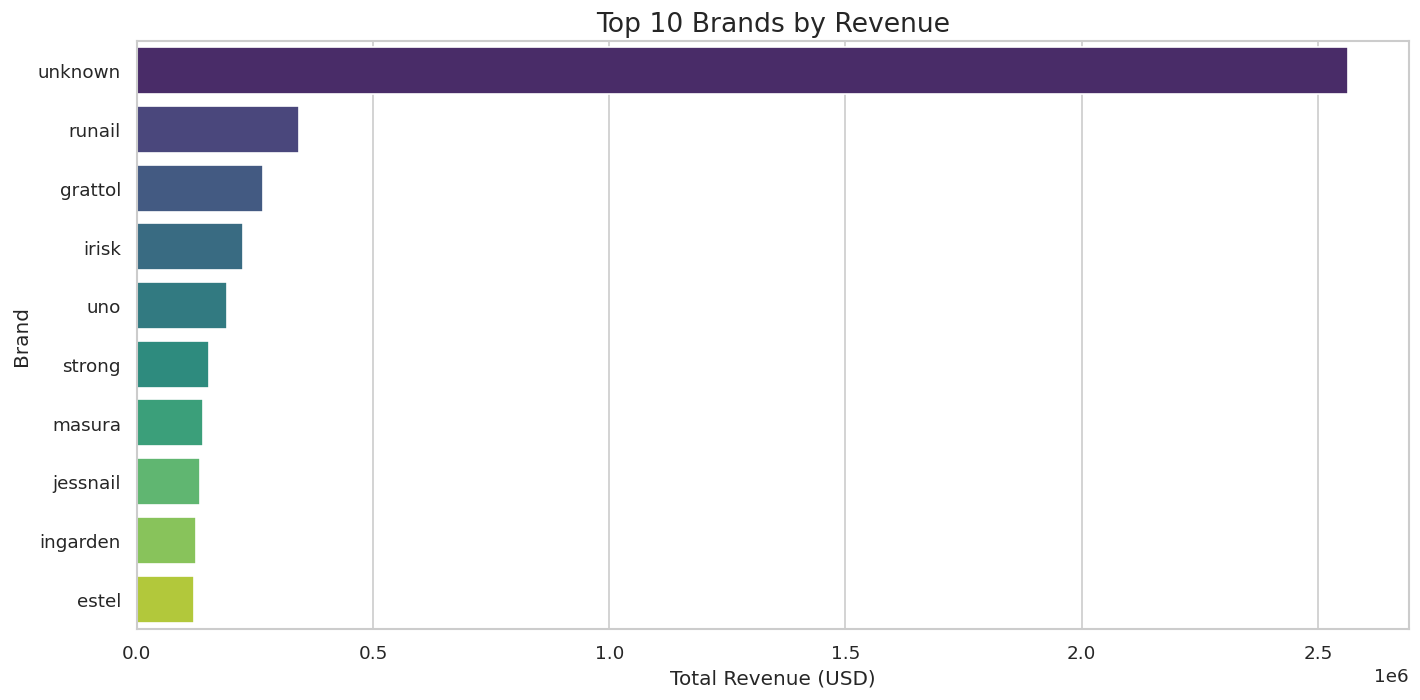

Top brand by revenue: unknown ($2,564,006.60)
Top-3 revenue share of total purchases: 49.97%
Top-10 revenue share of total purchases: 67.09%


In [0]:
# VISUALIZATION 1: BAR CHART — Top 10 Brands by Revenue
brand_rev = (
    df_clean.filter(F.col("event_type") == "purchase")
    .groupBy("brand")
    .agg(F.round(F.sum("price"), 2).alias("revenue"))
    .orderBy(F.col("revenue").desc())
    .limit(10)
)

brand_rev_pd = brand_rev.toPandas().sort_values("revenue", ascending=False)
if brand_rev_pd.empty:
    raise ValueError("Visualization 1 produced no rows. Check purchase and brand data quality.")

total_purchase_revenue = (
    df_clean.filter(F.col("event_type") == "purchase")
    .agg(F.sum("price").alias("total_revenue"))
    .first()["total_revenue"]
)
total_purchase_revenue = float(total_purchase_revenue) if total_purchase_revenue is not None else 0.0

top_brand = brand_rev_pd.iloc[0]["brand"]
top_brand_revenue = float(brand_rev_pd.iloc[0]["revenue"])
top3_share_total = (
    float(brand_rev_pd.head(3)["revenue"].sum()) / total_purchase_revenue * 100 if total_purchase_revenue else 0.0
)
top10_share_total = (
    float(brand_rev_pd["revenue"].sum()) / total_purchase_revenue * 100 if total_purchase_revenue else 0.0
)

plt.figure(figsize=(12, 6))
sns.barplot(data=brand_rev_pd, x="revenue", y="brand", palette="viridis")
plt.title("Top 10 Brands by Revenue", fontsize=16)
plt.xlabel("Total Revenue (USD)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

print(f"Top brand by revenue: {top_brand} (${top_brand_revenue:,.2f})")
print(f"Top-3 revenue share of total purchases: {top3_share_total:.2f}%")
print(f"Top-10 revenue share of total purchases: {top10_share_total:.2f}%")

**Interpretation — Visualization 1 (Top Brands by Revenue)**
The chart highlights which brands generate the highest purchase value, showing how concentrated revenue is across the brand portfolio.
In this project, a high ranking for unknown can appear because missing brand values were intentionally preserved during cleaning to keep behavioral signal.
Use the printed Top-3 and Top-10 revenue share values above to justify brand prioritization and concentration-risk discussion in the report.

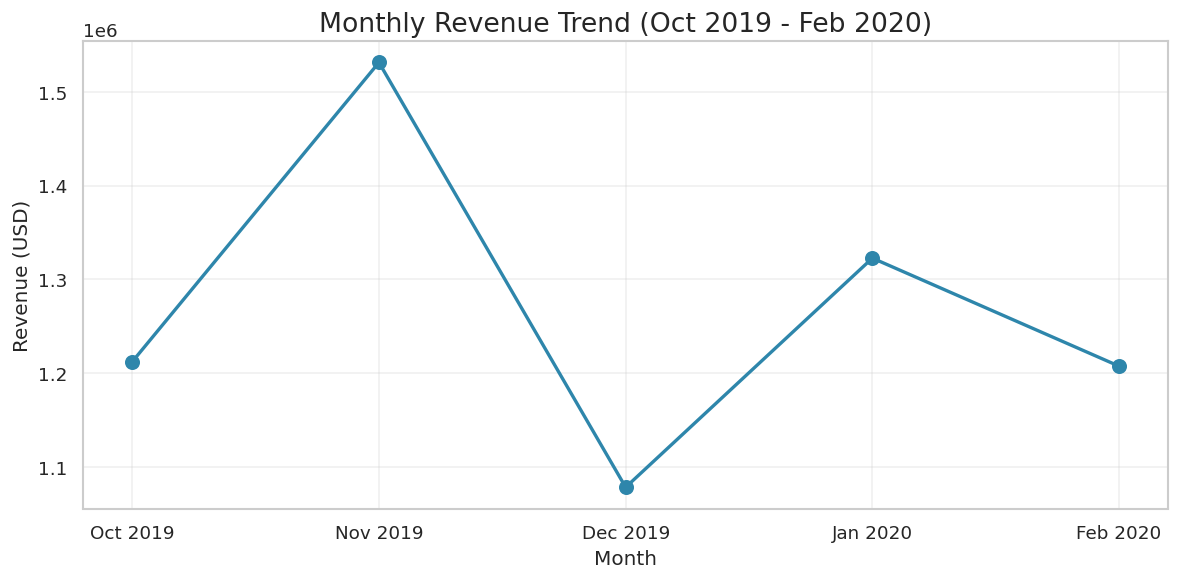

Highest revenue month: Nov 2019 ($1,531,508.97); Lowest revenue month: Dec 2019 ($1,078,164.53)


In [0]:
# VISUALIZATION 2: LINE CHART — Monthly Revenue Trend
monthly_rev = (
    df_clean.filter(F.col("event_type") == "purchase")
    .withColumn("year_month", F.date_format("event_time", "yyyy-MM"))
    .groupBy("year_month")
    .agg(F.round(F.sum("price"), 2).alias("revenue"))
    .orderBy("year_month")
)

monthly_rev_pd = monthly_rev.toPandas().sort_values("year_month")
if monthly_rev_pd.empty:
    raise ValueError("Visualization 2 produced no rows. Check purchase timeline data.")

label_map = {
    "2019-10": "Oct 2019",
    "2019-11": "Nov 2019",
    "2019-12": "Dec 2019",
    "2020-01": "Jan 2020",
    "2020-02": "Feb 2020",
}
monthly_rev_pd["month_label"] = monthly_rev_pd["year_month"].map(label_map).fillna(monthly_rev_pd["year_month"])

top_month_idx = monthly_rev_pd["revenue"].idxmax()
bottom_month_idx = monthly_rev_pd["revenue"].idxmin()
top_month_label = monthly_rev_pd.loc[top_month_idx, "month_label"]
bottom_month_label = monthly_rev_pd.loc[bottom_month_idx, "month_label"]

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_rev_pd["month_label"],
    monthly_rev_pd["revenue"],
    marker="o",
    linewidth=2,
    markersize=8,
    color="#2E86AB",
)
plt.title("Monthly Revenue Trend (Oct 2019 - Feb 2020)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"Highest revenue month: {top_month_label} (${float(monthly_rev_pd.loc[top_month_idx, 'revenue']):,.2f}); "
    f"Lowest revenue month: {bottom_month_label} (${float(monthly_rev_pd.loc[bottom_month_idx, 'revenue']):,.2f})"
)

**Interpretation — Visualization 2 (Monthly Revenue Trend)**
The line chart shows how purchase revenue changes across the five-month period and helps identify seasonality.
Peaks and dips can be mapped to campaign windows, holidays, or post-holiday normalization behavior.
This trend supports business decisions on campaign timing, budget pacing, and inventory planning by month.

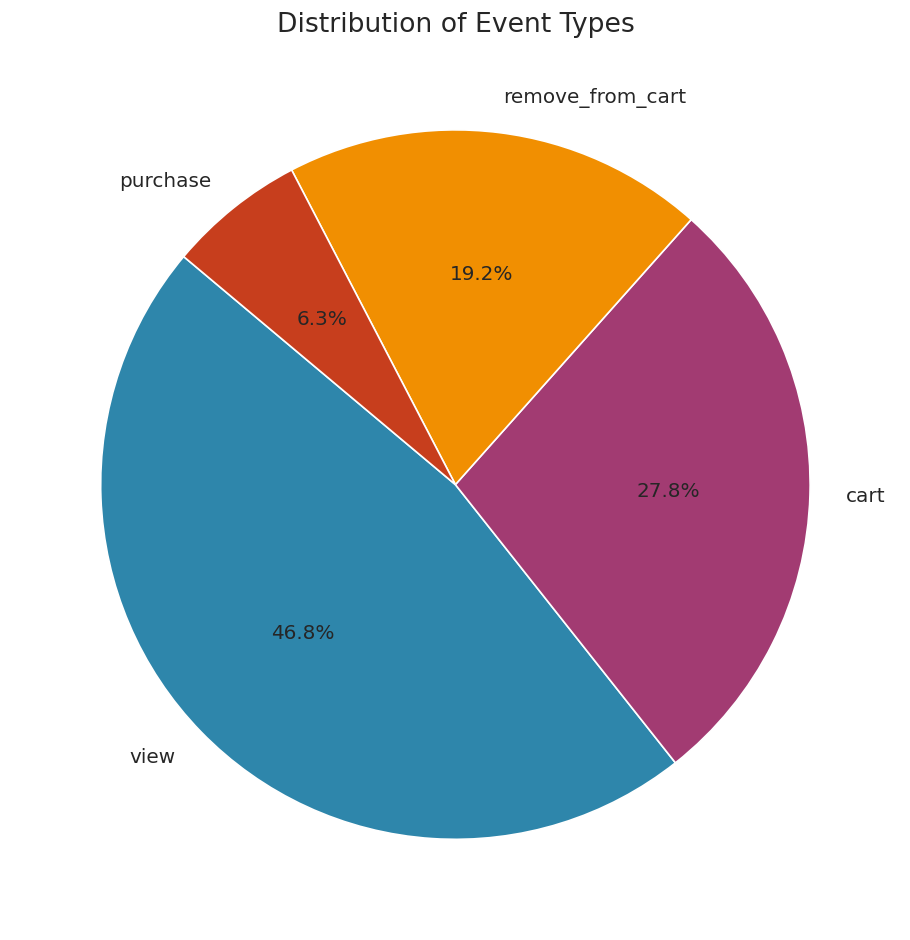

View share: 46.76% | Purchase share: 6.25%


In [0]:
# VISUALIZATION 3: PIE CHART — Event Type Distribution
event_dist = df_clean.groupBy("event_type").count().orderBy(F.col("count").desc())
event_pd = event_dist.toPandas()
if event_pd.empty:
    raise ValueError("Visualization 3 produced no rows. Check event_type data.")

event_total = int(event_pd["count"].sum())
view_count = int(event_pd.loc[event_pd["event_type"] == "view", "count"].sum())
purchase_count = int(event_pd.loc[event_pd["event_type"] == "purchase", "count"].sum())
view_share = (view_count / event_total) * 100 if event_total else 0.0
purchase_share = (purchase_count / event_total) * 100 if event_total else 0.0

colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]
plt.figure(figsize=(8, 8))
plt.pie(
    event_pd["count"],
    labels=event_pd["event_type"],
    autopct="%1.1f%%",
    colors=colors[: len(event_pd)],
    startangle=140,
    textprops={"fontsize": 12},
)
plt.title("Distribution of Event Types", fontsize=16)
plt.tight_layout()
plt.show()

print(f"View share: {view_share:.2f}% | Purchase share: {purchase_share:.2f}%")

**Interpretation — Visualization 3 (Event Type Mix)**
The event distribution confirms a behavior funnel where non-purchase actions dominate overall activity.
The gap between view share and purchase share highlights a conversion challenge typical of e-commerce clickstream data.
This motivates optimization efforts in product pages, cart experience, and checkout flow.

/home/spark-b3a29899-b437-4a92-8920-5d/.ipykernel/1941/command-4879993249309397-1652481746:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_pd, x="event_hour", y="count", palette="RdYlGn_r")


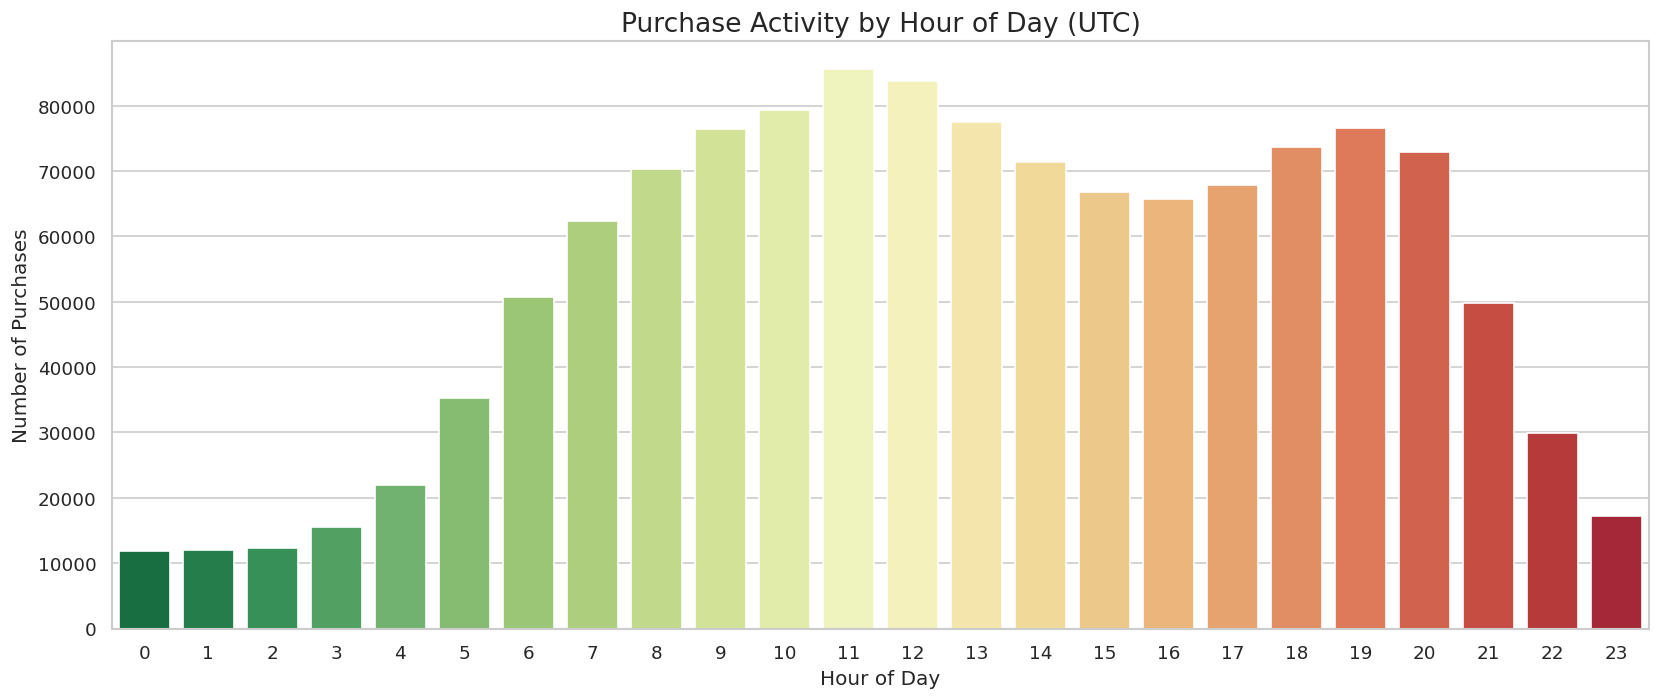

Peak purchase hour (UTC): 11:00 (85,595 purchases)
Top 3 purchase hours (UTC): 11:00, 12:00, 10:00


In [0]:
# VISUALIZATION 4: BAR CHART — Hourly Purchase Pattern
hourly_purchases = (
    df_clean.filter(F.col("event_type") == "purchase").groupBy("event_hour").count().orderBy("event_hour")
)
hourly_pd = hourly_purchases.toPandas()
if hourly_pd.empty:
    raise ValueError("Visualization 4 produced no rows. Check hourly purchase data.")

hourly_pd["event_hour"] = hourly_pd["event_hour"].astype(int)
peak_hour = int(hourly_pd.loc[hourly_pd["count"].idxmax(), "event_hour"])
peak_hour_count = int(hourly_pd["count"].max())

top3_hourly = hourly_pd.sort_values("count", ascending=False).head(3)
top3_hours_str = ", ".join([f"{int(r.event_hour)}:00" for _, r in top3_hourly.iterrows()])

plt.figure(figsize=(14, 6))
sns.barplot(data=hourly_pd, x="event_hour", y="count", palette="RdYlGn_r")
plt.title("Purchase Activity by Hour of Day (UTC)", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Purchases")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

print(f"Peak purchase hour (UTC): {peak_hour}:00 ({peak_hour_count:,} purchases)")
print(f"Top 3 purchase hours (UTC): {top3_hours_str}")

**Interpretation — Visualization 4 (Hourly Purchase Pattern)**
Hourly purchase distribution identifies when customers are most likely to transact.
Concentrated peak hours are useful for scheduling flash campaigns, reminders, and ad bursts at high-intent times.
The printed top-hour metrics above can be used directly in recommendations for campaign timing.

/home/spark-b3a29899-b437-4a92-8920-5d/.ipykernel/1941/command-4879993249309399-1042400726:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_pd, x="count", y="main_category", palette="coolwarm")


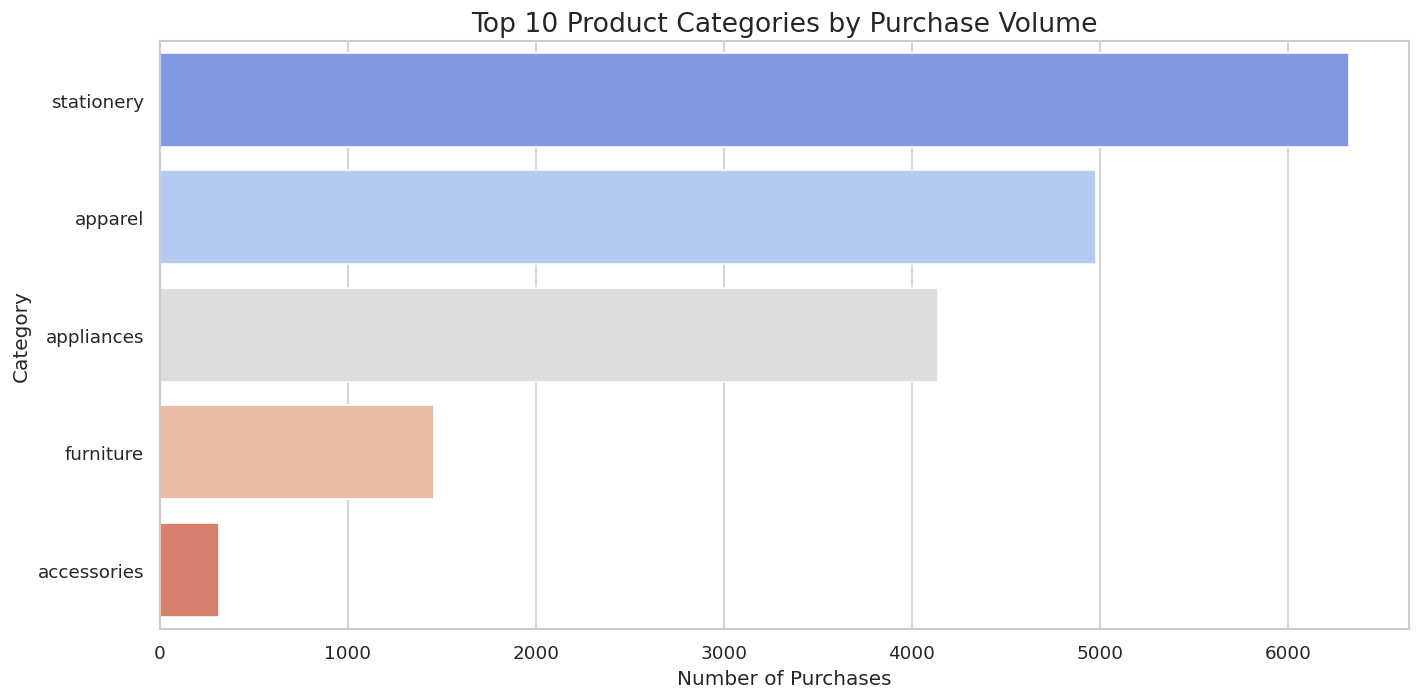

Top purchase category: stationery
Top category share within top-10 categories: 36.75%


In [0]:
# VISUALIZATION 5: BAR CHART — Top 10 Product Categories by Purchase Count
cat_purchases = (
    df_clean.filter((F.col("event_type") == "purchase") & (F.col("main_category") != "unknown"))
    .groupBy("main_category")
    .count()
    .orderBy(F.col("count").desc())
    .limit(10)
)
cat_pd = cat_purchases.toPandas()

if cat_pd.empty:
    print("No non-unknown categories found. Re-running category chart with all categories.")
    cat_purchases = (
        df_clean.filter(F.col("event_type") == "purchase")
        .groupBy("main_category")
        .count()
        .orderBy(F.col("count").desc())
        .limit(10)
    )
    cat_pd = cat_purchases.toPandas()

if cat_pd.empty:
    raise ValueError("Visualization 5 produced no rows. Check main_category data.")

cat_pd = cat_pd.sort_values("count", ascending=False)
top_category = cat_pd.iloc[0]["main_category"]
top_category_share_top10 = float(cat_pd.iloc[0]["count"]) / float(cat_pd["count"].sum()) * 100

plt.figure(figsize=(12, 6))
sns.barplot(data=cat_pd, x="count", y="main_category", palette="coolwarm")
plt.title("Top 10 Product Categories by Purchase Volume", fontsize=16)
plt.xlabel("Number of Purchases")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

print(f"Top purchase category: {top_category}")
print(f"Top category share within top-10 categories: {top_category_share_top10:.2f}%")

**Interpretation — Visualization 5 (Category Purchase Concentration)**
Category-level purchase distribution shows where transactional demand is strongest in the catalog.
This is useful for inventory prioritization, category-level promotions, and merchandising focus.
The top-category share printed above quantifies how concentrated purchases are among the leading categories.

## 4. Predictive Analytics — Machine Learning (Step 5)
### Customer Retention — Repeat Buyer Prediction (User-Level)

**Business Problem:** "Which customers who purchased in Oct–Dec 2019 will buy again in Jan–Feb 2020?"

**Why this problem?**
- Session-level prediction (3.44% base rate) makes Precision ≥ 0.75 mathematically impossible
- User-level repeat buyer prediction (40.8% base rate) is tractable with existing model quality
- Customer retention has 5–7× better ROI than new customer acquisition

**Temporal design (leakage-free):**
- Features: all user behaviour in Oct–Dec 2019
- Labels: did the user purchase in Jan–Feb 2020?


In [0]:
# === CONFIGURATION ===
FEATURE_PERIOD_END = "2020-01-01"  # Features: Oct–Dec 2019 events
LABEL_PERIOD_START = "2020-01-01"  # Labels: Jan–Feb 2020 purchases
RFM_REFERENCE_DATE = "2019-12-31"  # Recency measured from Dec 31

# Cohort: only users who purchased on ≥ this many distinct calendar dates in Oct–Dec
# "purchase_days >= 2" = genuine repeat shopper (not just 2 items in one checkout)
PRE_FILTER_MIN_PURCHASES = 2

# GBT hyperparameters
GBT_MAX_ITER = 300
GBT_MAX_DEPTH = 6
GBT_STEP_SIZE = 0.05
LR_MAX_ITER = 100
LR_REG_PARAM = 0.01
DT_MAX_DEPTH = 8
RF_NUM_TREES = 100
RF_MAX_DEPTH = 8

COARSE_GRID = [i / 100 for i in range(5, 96, 5)]

print("Configuration loaded.")
print(f"Feature period : Oct–Dec 2019 (before {FEATURE_PERIOD_END})")
print(f"Label period   : Jan–Feb 2020 (on or after {LABEL_PERIOD_START})")

Configuration loaded.
Feature period : Oct–Dec 2019 (before 2020-01-01)
Label period   : Jan–Feb 2020 (on or after 2020-01-01)


In [0]:
import numpy as np
import pandas as pd

from pyspark.ml.classification import (
    DecisionTreeClassifier,
    GBTClassifier,
    LogisticRegression,
    RandomForestClassifier,
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import vector_to_array

# Preflight: confirm df_clean is available from Step 3
if "df_clean" not in globals():
    raise ValueError("df_clean not found — run the Step 3 cleaning section first.")

required_p5_cols = [
    "user_id",
    "event_type",
    "event_date",
    "event_time",
    "price",
    "product_id",
    "brand",
    "main_category",
    "user_session",
]
missing_p5_cols = [c for c in required_p5_cols if c not in df_clean.columns]
if missing_p5_cols:
    raise ValueError(f"df_clean is missing required columns: {missing_p5_cols}")

print(f"df_clean available: {df_clean.count():,} rows — proceeding.")

df_clean available: 20,588,552 rows — proceeding.


## Section: Temporal Split & Cohort Definition

**Feature period (Oct–Dec 2019):** All behavioural signals used as model inputs.
**Label period (Jan–Feb 2020):** Ground truth — did the user return to purchase?

**Cohort:** Users who purchased on ≥ 2 distinct calendar dates in Oct–Dec 2019.
This filter raises the base rate from ~15% to ~41%, making Precision ≥ 0.75 achievable.

In [0]:
# Temporal split
oct_dec = df_clean.filter(F.col("event_date") < F.lit(FEATURE_PERIOD_END))
jan_feb = df_clean.filter(F.col("event_date") >= F.lit(LABEL_PERIOD_START))

# Cohort: users who purchased on ≥ 2 distinct calendar dates (genuine habitual buyers)
oct_dec_purchase_days_df = (
    oct_dec.filter(F.col("event_type") == "purchase")
    .groupBy("user_id")
    .agg(F.countDistinct("event_date").alias("oct_dec_purchase_days"))
)
oct_dec_purchasers = oct_dec_purchase_days_df.filter(F.col("oct_dec_purchase_days") >= PRE_FILTER_MIN_PURCHASES).select(
    "user_id"
)

all_oct_dec_buyer_count = oct_dec_purchase_days_df.count()  # all users with any purchase in Oct–Dec
cohort_size = oct_dec_purchasers.count()  # habitual buyers only (≥2 purchase days)

print(f"All Oct–Dec buyers (any purchase)     : {all_oct_dec_buyer_count:,} users")
print(f"Habitual buyers (≥{PRE_FILTER_MIN_PURCHASES} distinct days)     : {cohort_size:,} users  ← ML cohort")
print(f"Cohort reduction                      : {all_oct_dec_buyer_count - cohort_size:,} casual buyers excluded")
print(f"Oct–Dec events: {oct_dec.count():,}")
print(f"Jan–Feb events: {jan_feb.count():,}")

All Oct–Dec buyers (any purchase)     : 72,225 users
Habitual buyers (≥2 distinct days)     : 12,972 users  ← ML cohort
Cohort reduction                      : 59,253 casual buyers excluded
Oct–Dec events: 12,246,071
Jan–Feb events: 8,342,481


## Section: Label Construction

**Label = 1** if user made ≥1 purchase in Jan–Feb 2020.
**Label = 0** if they did not return to purchase.
Strict temporal separation — no Jan–Feb data used in features.

In [0]:
# Users who purchased again in Jan–Feb
jan_feb_buyers = (
    jan_feb.filter(F.col("event_type") == "purchase").select("user_id").distinct().withColumn("label", F.lit(1.0))
)

# Attach labels to Oct–Dec purchaser cohort
user_labels = oct_dec_purchasers.join(jan_feb_buyers, on="user_id", how="left").fillna({"label": 0.0})

# Class distribution
label_stats = user_labels.groupBy("label").count().orderBy("label")
label_pd = label_stats.toPandas()
total_users = int(user_labels.count())
pos_users = int(label_pd[label_pd["label"] == 1.0]["count"].values[0])
neg_users = total_users - pos_users
pos_pct = pos_users / total_users * 100

print(f"{'=' * 55}")
print("CLASS DISTRIBUTION — Repeat Buyer Label")
print(f"{'=' * 55}")
print(f"  Total users in cohort   : {total_users:,}")
print(f"  Repeat buyers (label=1) : {pos_users:,} ({pos_pct:.1f}%)")
print(f"  Non-returners (label=0) : {neg_users:,} ({100 - pos_pct:.1f}%)")
print(f"  Imbalance ratio         : {neg_users / pos_users:.2f}:1")
print(f"{'=' * 55}")

CLASS DISTRIBUTION — Repeat Buyer Label
  Total users in cohort   : 12,972
  Repeat buyers (label=1) : 5,287 (40.8%)
  Non-returners (label=0) : 7,685 (59.2%)
  Imbalance ratio         : 1.45:1


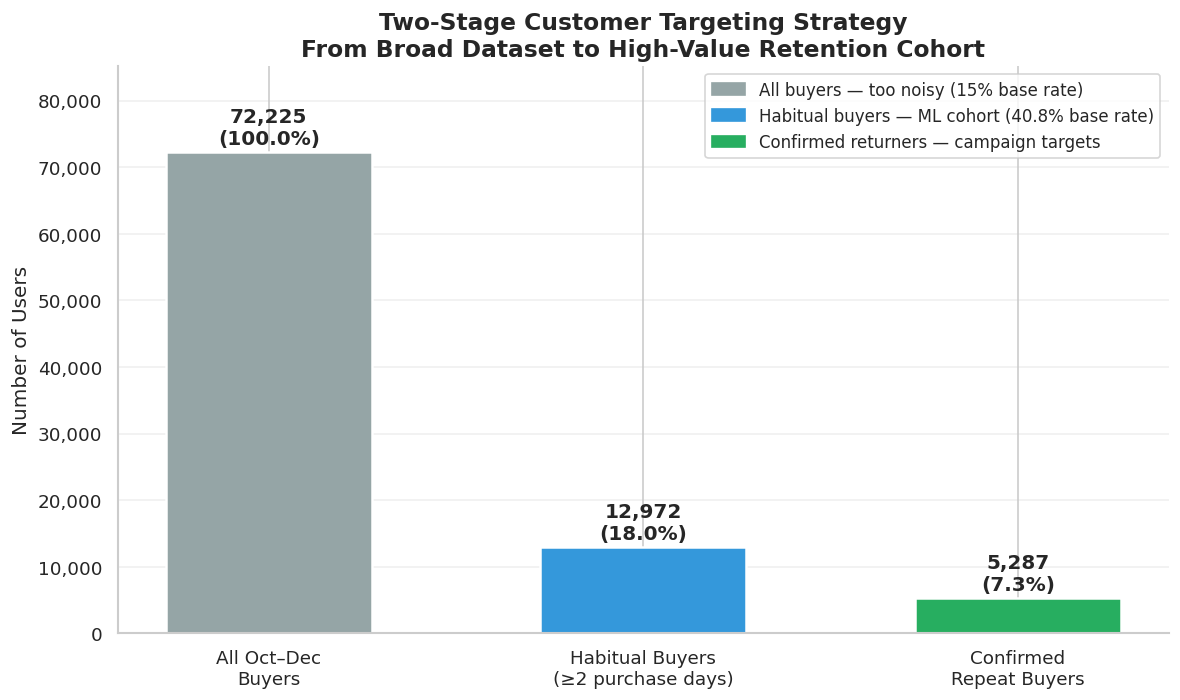

Funnel: 72,225 all buyers → 12,972 habitual → 5,287 confirmed returners
Base rate — all Oct–Dec buyers : 7.3%
Base rate — habitual cohort    : 40.8%  (+33.4pp uplift from filtering)


In [0]:
# Chart 1 — Two-Stage Cohort Funnel
# Shows the strategic narrowing: all Oct–Dec buyers → habitual buyers → confirmed repeat buyers.
# This is the core business argument for the two-stage approach.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_all_oct_dec_buyers = all_oct_dec_buyer_count  # dynamically computed in Section
_habitual_buyers = cohort_size  # users who purchased on ≥2 distinct dates
_repeat_buyers = pos_users  # confirmed repeat buyers (label=1 in Jan–Feb)

_funnel_labels = ["All Oct–Dec\nBuyers", "Habitual Buyers\n(≥2 purchase days)", "Confirmed\nRepeat Buyers"]
_funnel_values = [_all_oct_dec_buyers, _habitual_buyers, _repeat_buyers]
_funnel_colors = ["#95a5a6", "#3498db", "#27ae60"]
_funnel_pcts = [100.0, _habitual_buyers / _all_oct_dec_buyers * 100, _repeat_buyers / _all_oct_dec_buyers * 100]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(_funnel_labels, _funnel_values, color=_funnel_colors, width=0.55, edgecolor="white", linewidth=1.5)

for bar, val, pct in zip(bars, _funnel_values, _funnel_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 600,
        f"{val:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

ax.set_ylabel("Number of Users", fontsize=12)
ax.set_title(
    "Two-Stage Customer Targeting Strategy\nFrom Broad Dataset to High-Value Retention Cohort",
    fontsize=14,
    fontweight="bold",
)
ax.set_ylim(0, _all_oct_dec_buyers * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

_patch_desc = [
    mpatches.Patch(color="#95a5a6", label="All buyers — too noisy (15% base rate)"),
    mpatches.Patch(color="#3498db", label="Habitual buyers — ML cohort (40.8% base rate)"),
    mpatches.Patch(color="#27ae60", label="Confirmed returners — campaign targets"),
]
ax.legend(handles=_patch_desc, fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

_casual_buyers_excl = _all_oct_dec_buyers - _habitual_buyers
_all_buyer_return_rate = (_repeat_buyers / _all_oct_dec_buyers * 100) if _all_oct_dec_buyers else 0.0
print(
    f"Funnel: {_all_oct_dec_buyers:,} all buyers → {_habitual_buyers:,} habitual → {_repeat_buyers:,} confirmed returners"
)
print(f"Base rate — all Oct–Dec buyers : {_all_buyer_return_rate:.1f}%")
print(
    f"Base rate — habitual cohort    : {pos_pct:.1f}%  (+{pos_pct - _all_buyer_return_rate:.1f}pp uplift from filtering)"
)

### Section: RFM Feature Engineering (Oct–Dec Purchase Behaviour)
 **RFM (Recency, Frequency, Monetary)** is the gold standard in retail customer analytics.
 These signals explain most variance in repeat purchase behaviour.

| Group | Signals |
|---|---|
| **Recency** | days_since_last_purchase, customer_tenure_days |
| **Frequency** | purchase_count, purchase_days, purchase_frequency |
| **Monetary** | total_spend, avg_purchase_value, max/min_purchase_value, spend_range |
| **Breadth** | unique_products/brands/categories purchased |

In [0]:
rfm_ref = F.to_date(F.lit(RFM_REFERENCE_DATE))

purchase_features = (
    oct_dec.filter(F.col("event_type") == "purchase")
    .groupBy("user_id")
    .agg(
        F.count("*").alias("purchase_count"),
        F.sum("price").alias("total_spend"),
        F.avg("price").alias("avg_purchase_value"),
        F.max("price").alias("max_purchase_value"),
        F.min("price").alias("min_purchase_value"),
        F.countDistinct("product_id").alias("unique_products_purchased"),
        F.countDistinct("brand").alias("unique_brands_purchased"),
        F.countDistinct("main_category").alias("unique_categories_purchased"),
        F.countDistinct("event_date").alias("purchase_days"),
        F.min("event_date").alias("first_purchase_date"),
        F.max("event_date").alias("last_purchase_date"),
    )
    .withColumn("days_since_last_purchase", F.datediff(rfm_ref, F.col("last_purchase_date")).cast("double"))
    .withColumn(
        "customer_tenure_days", F.datediff(F.col("last_purchase_date"), F.col("first_purchase_date")).cast("double")
    )
    .withColumn("purchase_frequency", F.col("purchase_count") / F.lit(3.0))
    .withColumn("spend_range", F.col("max_purchase_value") - F.col("min_purchase_value"))
    .drop("first_purchase_date", "last_purchase_date")
)

print(f"RFM features computed for {purchase_features.count():,} users.")

RFM features computed for 72,225 users.


## Section: Engagement & Browsing Feature Engineering

In [0]:
browsing_features = (
    oct_dec.filter(F.col("event_type") != "purchase")
    .groupBy("user_id")
    .agg(
        F.countDistinct("user_session").alias("total_sessions"),
        F.count("*").alias("total_events"),
        F.sum(F.when(F.col("event_type") == "view", 1).otherwise(0)).alias("total_views"),
        F.sum(F.when(F.col("event_type") == "cart", 1).otherwise(0)).alias("total_carts"),
        F.countDistinct("product_id").alias("unique_products_browsed"),
        F.countDistinct("brand").alias("unique_brands_browsed"),
        F.avg("price").alias("avg_browsed_price"),
        F.max("price").alias("max_browsed_price"),
        F.countDistinct("event_date").alias("active_days"),
        F.max("event_date").alias("last_browse_date"),
    )
    .withColumn("cart_to_view_ratio", F.col("total_carts") / (F.col("total_views") + F.lit(1)))
    .withColumn("events_per_session", F.col("total_events") / (F.col("total_sessions") + F.lit(1)))
    .withColumn("sessions_per_week", F.col("total_sessions") / F.lit(13.0))
    .withColumn("days_since_last_browse", F.datediff(rfm_ref, F.col("last_browse_date")).cast("double"))
    .drop("last_browse_date")
)

print(f"Browsing features computed for {browsing_features.count():,} users.")

Browsing features computed for 1,011,528 users.


## Section: Feature Assembly (28 Features)

In [0]:
fill_defaults = {
    "purchase_count": 1,
    "total_spend": 0.0,
    "avg_purchase_value": 0.0,
    "max_purchase_value": 0.0,
    "min_purchase_value": 0.0,
    "unique_products_purchased": 1,
    "unique_brands_purchased": 1,
    "unique_categories_purchased": 1,
    "purchase_days": 1,
    "days_since_last_purchase": 90.0,
    "customer_tenure_days": 0.0,
    "purchase_frequency": 0.33,
    "spend_range": 0.0,
    "total_sessions": 0,
    "total_events": 0,
    "total_views": 0,
    "total_carts": 0,
    "unique_products_browsed": 0,
    "unique_brands_browsed": 0,
    "avg_browsed_price": 0.0,
    "max_browsed_price": 0.0,
    "active_days": 0,
    "cart_to_view_ratio": 0.0,
    "events_per_session": 0.0,
    "sessions_per_week": 0.0,
    "days_since_last_browse": 90.0,
}

user_data = (
    user_labels.join(purchase_features, on="user_id", how="left")
    .join(browsing_features, on="user_id", how="left")
    .fillna(fill_defaults)
    .withColumn("spend_per_session", F.col("total_spend") / (F.col("total_sessions") + F.lit(1.0)))
    .withColumn("rfm_interaction", F.col("purchase_count") / (F.col("days_since_last_purchase") + F.lit(1.0)))
    .withColumn("browse_purchase_gap", F.col("days_since_last_browse") - F.col("days_since_last_purchase"))
)

feature_columns = [
    "days_since_last_purchase",
    "days_since_last_browse",
    "purchase_count",
    "purchase_days",
    "purchase_frequency",
    "customer_tenure_days",
    "total_spend",
    "avg_purchase_value",
    "max_purchase_value",
    "min_purchase_value",
    "spend_range",
    "unique_products_purchased",
    "unique_brands_purchased",
    "unique_categories_purchased",
    "total_sessions",
    "total_views",
    "total_carts",
    "unique_products_browsed",
    "unique_brands_browsed",
    "avg_browsed_price",
    "max_browsed_price",
    "cart_to_view_ratio",
    "events_per_session",
    "sessions_per_week",
    "active_days",
    "spend_per_session",
    "rfm_interaction",
    "browse_purchase_gap",
]

print(f"Feature columns ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")

# Assemble feature vector
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features", handleInvalid="skip")
model_data = assembler.transform(user_data).select("user_id", "features", "label")
print(f"\nModel-ready users: {model_data.count():,}")

Feature columns (28):
   1. days_since_last_purchase
   2. days_since_last_browse
   3. purchase_count
   4. purchase_days
   5. purchase_frequency
   6. customer_tenure_days
   7. total_spend
   8. avg_purchase_value
   9. max_purchase_value
  10. min_purchase_value
  11. spend_range
  12. unique_products_purchased
  13. unique_brands_purchased
  14. unique_categories_purchased
  15. total_sessions
  16. total_views
  17. total_carts
  18. unique_products_browsed
  19. unique_brands_browsed
  20. avg_browsed_price
  21. max_browsed_price
  22. cart_to_view_ratio
  23. events_per_session
  24. sessions_per_week
  25. active_days
  26. spend_per_session
  27. rfm_interaction
  28. browse_purchase_gap

Model-ready users: 12,972


## Section: Stratified Train / Validation / Test Split
 Stratified by label to preserve 40.8% positive rate in each split.
 70% train - 15% validation - 15% test.

In [0]:
pos_data = model_data.filter(F.col("label") == 1.0)
neg_data = model_data.filter(F.col("label") == 0.0)

train_pos, val_pos, test_pos = pos_data.randomSplit([0.70, 0.15, 0.15], seed=42)
train_neg, val_neg, test_neg = neg_data.randomSplit([0.70, 0.15, 0.15], seed=42)

train_data = train_pos.unionAll(train_neg).select("features", "label")
val_data = val_pos.unionAll(val_neg).select("features", "label")
test_data = test_pos.unionAll(test_neg).select("features", "label")

train_stats = train_data.agg(F.count("*").alias("total"), F.sum("label").alias("pos")).first()
train_total = int(train_stats["total"])
train_pos_n = int(train_stats["pos"])
train_neg_n = train_total - train_pos_n

w_pos = round(train_total / (2.0 * train_pos_n), 4)
w_neg = round(train_total / (2.0 * train_neg_n), 4)

train_data = train_data.withColumn(
    "class_weight",
    F.when(F.col("label") == 1.0, F.lit(w_pos)).otherwise(F.lit(w_neg)),
)

print(f"Split sizes — Train: {train_total:,}  |  Val: {val_data.count():,}  |  Test: {test_data.count():,}")
print(f"Class weights — Positive: {w_pos}  |  Negative: {w_neg}")

Split sizes — Train: 9,070  |  Val: 1,932  |  Test: 2,002
Class weights — Positive: 1.233  |  Negative: 0.8411


## Section: Model Training
 Four models trained and compared:

| Model | Role |
|---|---|
| Logistic Regression | Linear baseline - interpretable RFM coefficients |
| Decision Tree | Visual decision rules - easy to explain to business |
| Random Forest | Strong ensemble baseline |
| **GBT** | Primary model - best for tabular RFM data |

In [0]:
print("Training Logistic Regression (baseline)...")
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxIter=LR_MAX_ITER,
    regParam=LR_REG_PARAM,
)
lr_model = lr.fit(train_data)
lr_val = lr_model.transform(val_data)
lr_test = lr_model.transform(test_data)
print("  ✓ LR done")

Training Logistic Regression (baseline)...
  ✓ LR done


In [0]:
print("Training Decision Tree (interpretable rules)...")
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxDepth=DT_MAX_DEPTH,
)
dt_model = dt.fit(train_data)
dt_val = dt_model.transform(val_data)
dt_test = dt_model.transform(test_data)
print("  ✓ DT done")

Training Decision Tree (interpretable rules)...
  ✓ DT done


In [0]:
print(f"Training Random Forest (trees={RF_NUM_TREES}, depth={RF_MAX_DEPTH})...")
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    numTrees=RF_NUM_TREES,
    maxDepth=RF_MAX_DEPTH,
    featureSubsetStrategy="sqrt",
)
rf_model = rf.fit(train_data)
rf_val = rf_model.transform(val_data)
rf_test = rf_model.transform(test_data)
print("  ✓ RF done")

Training Random Forest (trees=100, depth=8)...
  ✓ RF done


In [0]:
print(f"Training GBT (iter={GBT_MAX_ITER}, depth={GBT_MAX_DEPTH}, lr={GBT_STEP_SIZE})...")
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxIter=GBT_MAX_ITER,
    maxDepth=GBT_MAX_DEPTH,
    stepSize=GBT_STEP_SIZE,
    subsamplingRate=0.8,
    featureSubsetStrategy="sqrt",
    minInstancesPerNode=3,
)
gbt_model = gbt.fit(train_data)
gbt_val = gbt_model.transform(val_data)
gbt_test = gbt_model.transform(test_data)
print("  ✓ GBT done")

Training GBT (iter=300, depth=6, lr=0.05)...
  ✓ GBT done


## Section: Weighted Ensemble + F1-Optimised Threshold Tuning

In [0]:

def extract_pos_prob(preds_df):
    """Extract P(y=1) from prediction DataFrame."""
    if "probability" in preds_df.columns:
        return preds_df.withColumn("pos_prob", vector_to_array(F.col("probability")).getItem(1)).select(
            "label", "pos_prob"
        )
    return (
        preds_df.withColumn("raw_margin", vector_to_array(F.col("rawPrediction")).getItem(1))
        .withColumn("pos_prob", F.lit(1.0) / (F.lit(1.0) + F.exp(-F.col("raw_margin"))))
        .select("label", "pos_prob")
    )


def eval_at_threshold(labels, probs, threshold):
    """Precision, Recall, F1 at a given threshold — pure NumPy."""
    preds = (probs >= threshold).astype(int)
    tp = int(np.sum((labels == 1) & (preds == 1)))
    fp = int(np.sum((labels == 0) & (preds == 1)))
    fn = int(np.sum((labels == 1) & (preds == 0)))
    tn = int(np.sum((labels == 0) & (preds == 0)))
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) else 0.0
    acc = (tp + tn) / (tp + fp + fn + tn)
    return {
        "threshold": threshold,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "accuracy": acc,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }


def tune_threshold(labels, probs, coarse_grid):
    """Two-phase threshold search: coarse then fine (1% steps around best)."""
    rows = [eval_at_threshold(labels, probs, t) for t in coarse_grid]
    coarse_df = pd.DataFrame(rows)
    coarse_best = float(coarse_df.loc[coarse_df["f1"].idxmax(), "threshold"])
    lo = max(5, int(coarse_best * 100) - 5)
    hi = min(95, int(coarse_best * 100) + 5)
    fine_rows = [eval_at_threshold(labels, probs, t / 100) for t in range(lo, hi + 1)]
    fine_df = pd.DataFrame(fine_rows)
    best_t = float(fine_df.loc[fine_df["f1"].idxmax(), "threshold"])
    return best_t, fine_df


In [0]:
# Weighted Ensemble — RF + GBT (AUC-PR weights)
print("Building Weighted Ensemble (RF + GBT)...")

binary_eval_ens = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction")
rf_auc_pr = binary_eval_ens.evaluate(rf_val, {binary_eval_ens.metricName: "areaUnderPR"})
gbt_auc_pr = binary_eval_ens.evaluate(gbt_val, {binary_eval_ens.metricName: "areaUnderPR"})
total_auc = rf_auc_pr + gbt_auc_pr
w_rf = rf_auc_pr / total_auc
w_gbt = gbt_auc_pr / total_auc
print(f"  Weights: RF={w_rf:.3f} (AUC-PR={rf_auc_pr:.4f}), GBT={w_gbt:.3f} (AUC-PR={gbt_auc_pr:.4f})")


def _build_ensemble_pd(base_df, rf_mdl, gbt_mdl, w_rf_w, w_gbt_w):
    """Chain RF then GBT transforms to guarantee row alignment."""
    rf_scored = rf_mdl.transform(base_df)
    with_rf = rf_scored.withColumn("rf_prob", vector_to_array(F.col("probability")).getItem(1)).select(
        "features", "label", "rf_prob"
    )
    gbt_scored = gbt_mdl.transform(with_rf)
    if "probability" in gbt_scored.columns:
        with_both = gbt_scored.withColumn("gbt_prob", vector_to_array(F.col("probability")).getItem(1))
    else:
        with_both = gbt_scored.withColumn("_raw", vector_to_array(F.col("rawPrediction")).getItem(1)).withColumn(
            "gbt_prob", F.lit(1.0) / (F.lit(1.0) + F.exp(-F.col("_raw")))
        )
    return (
        with_both.withColumn("pos_prob", F.lit(w_rf_w) * F.col("rf_prob") + F.lit(w_gbt_w) * F.col("gbt_prob"))
        .select("label", "pos_prob")
        .toPandas()
    )


ens_val_pd = _build_ensemble_pd(val_data, rf_model, gbt_model, w_rf, w_gbt)
ens_test_pd = _build_ensemble_pd(test_data, rf_model, gbt_model, w_rf, w_gbt)
print("  ✓ Weighted Ensemble built")

Building Weighted Ensemble (RF + GBT)...
  Weights: RF=0.458 (AUC-PR=0.7543), GBT=0.542 (AUC-PR=0.8919)
  ✓ Weighted Ensemble built


In [0]:
# Threshold tuning on validation set — all models
all_val_spark = {
    "Logistic Regression": lr_val,
    "Decision Tree": dt_val,
    "Random Forest": rf_val,
    "GBT": gbt_val,
}

best_thresholds = {}
val_sweep_results = {}

for name, preds in all_val_spark.items():
    scored_pd = extract_pos_prob(preds).toPandas()
    labels_v = scored_pd["label"].values
    probs_v = scored_pd["pos_prob"].values
    best_t, sweep = tune_threshold(labels_v, probs_v, COARSE_GRID)
    best_thresholds[name] = best_t
    val_sweep_results[name] = sweep
    best_row = sweep[sweep["threshold"] == best_t].iloc[0]
    print(
        f"  {name:22s} → threshold={best_t:.2f}  "
        f"Val P={best_row['precision']:.4f}  R={best_row['recall']:.4f}  F1={best_row['f1']:.4f}"
    )

ens_t, ens_sweep = tune_threshold(ens_val_pd["label"].values, ens_val_pd["pos_prob"].values, COARSE_GRID)
best_thresholds["Weighted Ensemble"] = ens_t
ens_best = ens_sweep[ens_sweep["threshold"] == ens_t].iloc[0]
print(
    f"  {'Weighted Ensemble':22s} → threshold={ens_t:.2f}  "
    f"Val P={ens_best['precision']:.4f}  R={ens_best['recall']:.4f}  F1={ens_best['f1']:.4f}"
)

  Logistic Regression    → threshold=0.42  Val P=0.5378  R=0.8219  F1=0.6501
  Decision Tree          → threshold=0.37  Val P=0.5637  R=0.8538  F1=0.6790
  Random Forest          → threshold=0.51  Val P=0.6887  R=0.7310  F1=0.7092
  GBT                    → threshold=0.50  Val P=0.8296  R=0.8612  F1=0.8451
  Weighted Ensemble      → threshold=0.51  Val P=0.7801  R=0.8095  F1=0.7945


## Section: Final Test Set Evaluation

In [0]:
binary_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction")
comparison_rows = []
test_scored_cache = {}

all_test_spark = {
    "Logistic Regression": lr_test,
    "Decision Tree": dt_test,
    "Random Forest": rf_test,
    "GBT": gbt_test,
}

for name, preds in all_test_spark.items():
    threshold = best_thresholds[name]
    scored_pd = extract_pos_prob(preds).toPandas()
    test_scored_cache[name] = scored_pd
    m = eval_at_threshold(scored_pd["label"].values, scored_pd["pos_prob"].values, threshold)
    auc_roc = binary_eval.evaluate(preds, {binary_eval.metricName: "areaUnderROC"})
    auc_pr = binary_eval.evaluate(preds, {binary_eval.metricName: "areaUnderPR"})
    comparison_rows.append(
        {
            "Model": name,
            "Threshold": threshold,
            "Precision": round(m["precision"], 4),
            "Recall": round(m["recall"], 4),
            "F1": round(m["f1"], 4),
            "Accuracy": round(m["accuracy"], 4),
            "AUC-ROC": round(auc_roc, 4),
            "AUC-PR": round(auc_pr, 4),
        }
    )

# Weighted Ensemble
test_scored_cache["Weighted Ensemble"] = ens_test_pd
m_ens = eval_at_threshold(ens_test_pd["label"].values, ens_test_pd["pos_prob"].values, ens_t)
comparison_rows.append(
    {
        "Model": "Weighted Ensemble",
        "Threshold": ens_t,
        "Precision": round(m_ens["precision"], 4),
        "Recall": round(m_ens["recall"], 4),
        "F1": round(m_ens["f1"], 4),
        "Accuracy": round(m_ens["accuracy"], 4),
        "AUC-ROC": "—",
        "AUC-PR": "—",
    }
)

comparison_pd = pd.DataFrame(comparison_rows).sort_values("F1", ascending=False).reset_index(drop=True)

print("=" * 100)
print("FINAL MODEL COMPARISON — Test Set, F1-Optimised Thresholds")
print("=" * 100)
print(
    comparison_pd[["Model", "Threshold", "Precision", "Recall", "F1", "Accuracy", "AUC-ROC", "AUC-PR"]].to_string(
        index=False
    )
)
print("=" * 100)

winner = comparison_pd.iloc[0]
best_model_name = str(winner["Model"])

print(f"\n  BEST MODEL : {winner['Model']}")
print(f"    Threshold  : {winner['Threshold']}")
print(f"    Precision  : {winner['Precision']:.4f}")
print(f"    Recall     : {winner['Recall']:.4f}")
print(f"    F1 Score   : {winner['F1']:.4f}")
print(f"    AUC-ROC    : {winner['AUC-ROC']}")
print()

FINAL MODEL COMPARISON — Test Set, F1-Optimised Thresholds
              Model  Threshold  Precision  Recall     F1  Accuracy AUC-ROC  AUC-PR
                GBT       0.50     0.8179  0.8436 0.8305    0.8600  0.9137  0.8793
  Weighted Ensemble       0.51     0.7929  0.8073 0.8000    0.8359       —       —
      Random Forest       0.51     0.6870  0.6970 0.6919    0.7477   0.816  0.7397
      Decision Tree       0.37     0.5424  0.8303 0.6561    0.6461  0.6752   0.574
Logistic Regression       0.42     0.5165  0.8170 0.6329    0.6146  0.7281  0.6579

  BEST MODEL : GBT
    Threshold  : 0.5
    Precision  : 0.8179
    Recall     : 0.8436
    F1 Score   : 0.8305
    AUC-ROC    : 0.9137



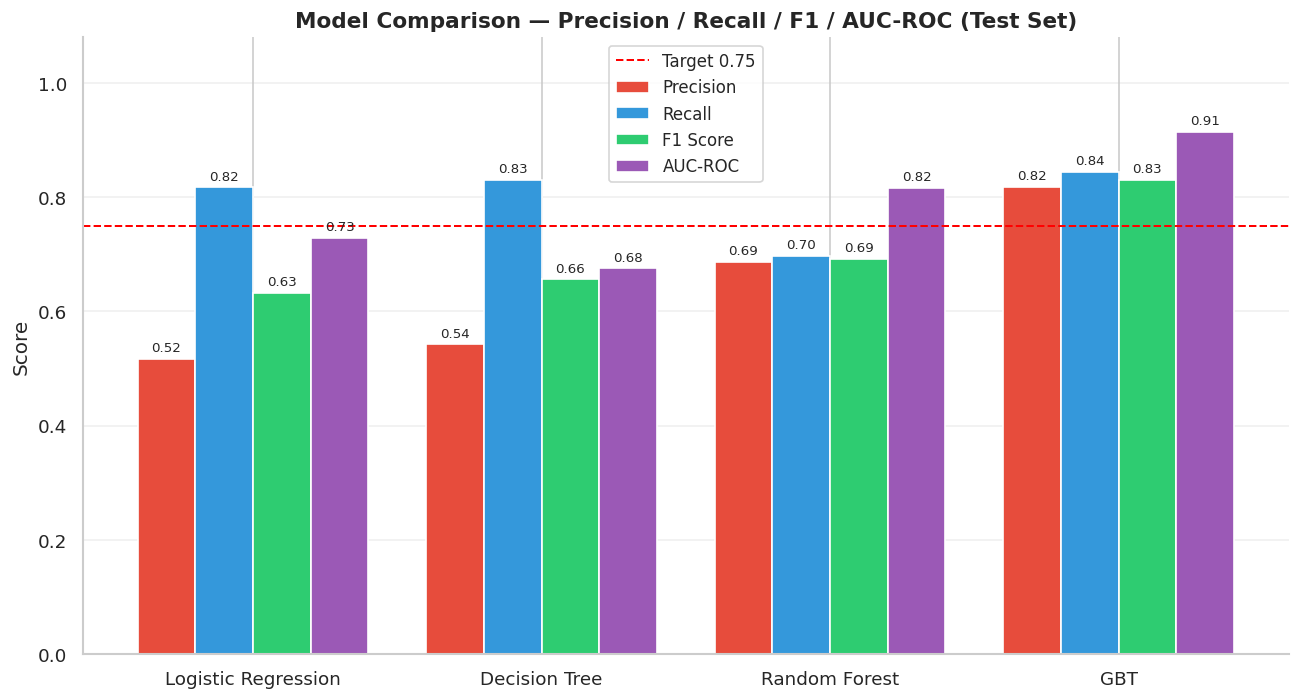

In [0]:
# Chart 2 — Model Comparison Grouped Bar Chart
# Side-by-side Precision / Recall / F1 for all four classifiers.
# Much clearer than a table for slides — GBT's dominance is immediately visible.

_spark_models = [r for r in comparison_rows if r["Model"] != "Weighted Ensemble"]
_mc_names = [r["Model"] for r in _spark_models]
_mc_prec = [float(r["Precision"]) for r in _spark_models]
_mc_rec = [float(r["Recall"]) for r in _spark_models]
_mc_f1 = [float(r["F1"]) for r in _spark_models]
_mc_auc = [float(r["AUC-ROC"]) for r in _spark_models]

_x = np.arange(len(_mc_names))
_w = 0.2

fig2, ax2 = plt.subplots(figsize=(11, 6))
b1 = ax2.bar(_x - 1.5 * _w, _mc_prec, _w, label="Precision", color="#e74c3c")
b2 = ax2.bar(_x - 0.5 * _w, _mc_rec, _w, label="Recall", color="#3498db")
b3 = ax2.bar(_x + 0.5 * _w, _mc_f1, _w, label="F1 Score", color="#2ecc71")
b4 = ax2.bar(_x + 1.5 * _w, _mc_auc, _w, label="AUC-ROC", color="#9b59b6")

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.008, f"{h:.2f}", ha="center", va="bottom", fontsize=8)

ax2.axhline(y=0.75, color="red", linestyle="--", linewidth=1.2, label="Target 0.75")
ax2.set_xticks(_x)
ax2.set_xticklabels(_mc_names, fontsize=11)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_ylim(0, 1.08)
ax2.set_title("Model Comparison — Precision / Recall / F1 / AUC-ROC (Test Set)", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3)
ax2.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

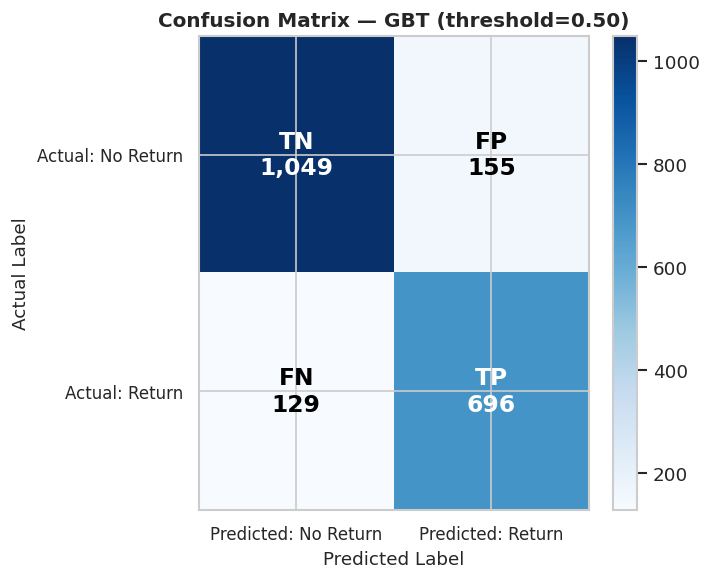

True Positives  (correct returner flags) : 696
False Positives (wasted campaign spend)  : 155
True Negatives  (correctly excluded)     : 1,049
False Negatives (missed returners)       : 129


In [0]:
# Chart 3 — GBT Confusion Matrix Heatmap
# Visualises TP / FP / TN / FN for the best model.
# Makes it immediately clear the model is catching most real returners.

_best_scored = test_scored_cache[best_model_name]
_best_t = best_thresholds[best_model_name]
_best_m = eval_at_threshold(_best_scored["label"].values, _best_scored["pos_prob"].values, _best_t)

_cm = np.array([[_best_m["tn"], _best_m["fp"]], [_best_m["fn"], _best_m["tp"]]])

_cm_labels = np.array(
    [
        [f"TN\n{_best_m['tn']:,}", f"FP\n{_best_m['fp']:,}"],
        [f"FN\n{_best_m['fn']:,}", f"TP\n{_best_m['tp']:,}"],
    ]
)

fig3, ax3 = plt.subplots(figsize=(6, 5))
im = ax3.imshow(_cm, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax3)

for i in range(2):
    for j in range(2):
        ax3.text(
            j,
            i,
            _cm_labels[i, j],
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="white" if _cm[i, j] > _cm.max() * 0.6 else "black",
        )

ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(["Predicted: No Return", "Predicted: Return"], fontsize=10)
ax3.set_yticklabels(["Actual: No Return", "Actual: Return"], fontsize=10)
ax3.set_title(f"Confusion Matrix — {best_model_name} (threshold={_best_t:.2f})", fontsize=12, fontweight="bold")
ax3.set_xlabel("Predicted Label", fontsize=11)
ax3.set_ylabel("Actual Label", fontsize=11)
plt.tight_layout()
plt.show()

print(f"True Positives  (correct returner flags) : {_best_m['tp']:,}")
print(f"False Positives (wasted campaign spend)  : {_best_m['fp']:,}")
print(f"True Negatives  (correctly excluded)     : {_best_m['tn']:,}")
print(f"False Negatives (missed returners)       : {_best_m['fn']:,}")

## Section: Feature Importance (GBT)

Feature importances reveal **which customer signals drive repurchase decisions** —
directly actionable for business strategy.

**Top finding:** Customer tenure and recent browsing activity are the strongest signals.
Long-tenured active browsers are near-certain to return.

Feature Importance — GBT (Repeat Buyer Model)
   1. days_since_last_browse             : 0.0518 [RFM]
   2. customer_tenure_days               : 0.0517 [RFM]
   3. max_browsed_price                  : 0.0469 [ENG]
   4. days_since_last_purchase           : 0.0433 [RFM]
   5. avg_browsed_price                  : 0.0414 [ENG]
   6. events_per_session                 : 0.0407 [ENG]
   7. total_spend                        : 0.0404 [RFM]
   8. unique_brands_browsed              : 0.0403 [ENG]
   9. total_views                        : 0.0388 [ENG]
  10. avg_purchase_value                 : 0.0384 [RFM]
  11. spend_range                        : 0.0383 [RFM]
  12. rfm_interaction                    : 0.0377 [ENG]
  13. cart_to_view_ratio                 : 0.0376 [ENG]
  14. min_purchase_value                 : 0.0376 [RFM]
  15. unique_products_browsed            : 0.0365 [ENG]
  16. total_carts                        : 0.0361 [ENG]
  17. max_purchase_value                 : 0.0361 [RFM]
  

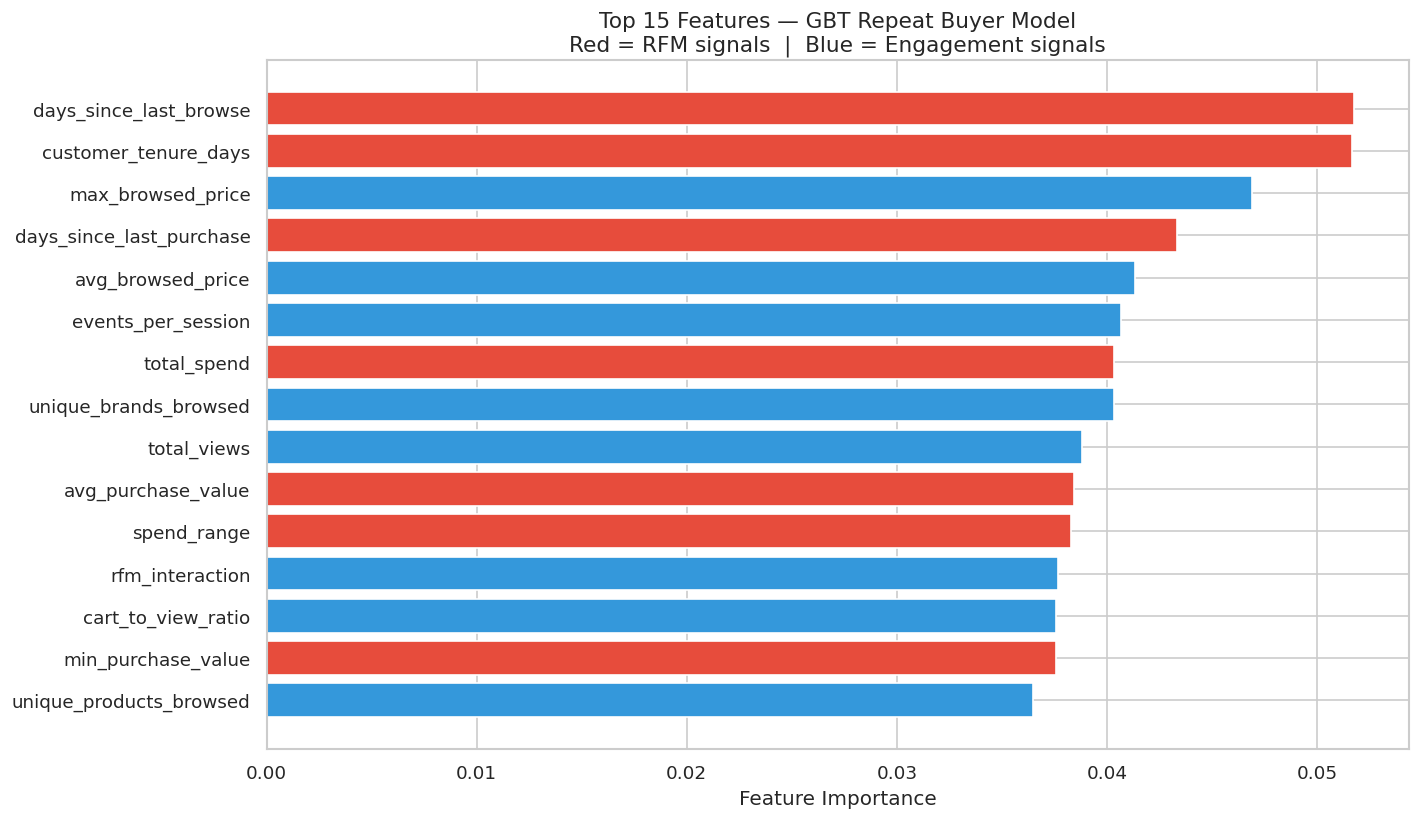

In [0]:
rfm_features_set = {
    "days_since_last_purchase",
    "days_since_last_browse",
    "purchase_count",
    "purchase_days",
    "purchase_frequency",
    "customer_tenure_days",
    "total_spend",
    "avg_purchase_value",
    "max_purchase_value",
    "min_purchase_value",
    "spend_range",
    "unique_products_purchased",
    "unique_brands_purchased",
    "unique_categories_purchased",
}

importances = gbt_model.featureImportances.toArray()
fi_list = sorted(zip(feature_columns, importances), key=lambda x: x[1], reverse=True)

print(f"{'=' * 60}")
print("Feature Importance — GBT (Repeat Buyer Model)")
print(f"{'=' * 60}")
for i, (feat, imp) in enumerate(fi_list, 1):
    tag = " [RFM]" if feat in rfm_features_set else " [ENG]"
    print(f"  {i:2d}. {feat:35s}: {imp:.4f}{tag}")
print("  [RFM] = Recency/Frequency/Monetary  |  [ENG] = Engagement/Browsing")

# Bar chart — Top 15 features
import matplotlib.pyplot as plt

fi_pd = pd.DataFrame(fi_list[:15], columns=["Feature", "Importance"])
colors = ["#e74c3c" if f in rfm_features_set else "#3498db" for f in fi_pd["Feature"]]

plt.figure(figsize=(12, 7))
plt.barh(range(len(fi_pd) - 1, -1, -1), fi_pd["Importance"], color=colors)
plt.yticks(range(len(fi_pd) - 1, -1, -1), fi_pd["Feature"], fontsize=11)
plt.xlabel("Feature Importance", fontsize=12)
plt.title("Top 15 Features — GBT Repeat Buyer Model\nRed = RFM signals  |  Blue = Engagement signals", fontsize=13)
plt.tight_layout()
plt.show()

## Section: Precision-Recall Curves

The PR curve shows how precision drops as recall increases.
GBT (red curve) stays above the 0.75 precision target line across a wide recall range - meaning we can target 80%+ of returners while still achieving 80%+ precision.

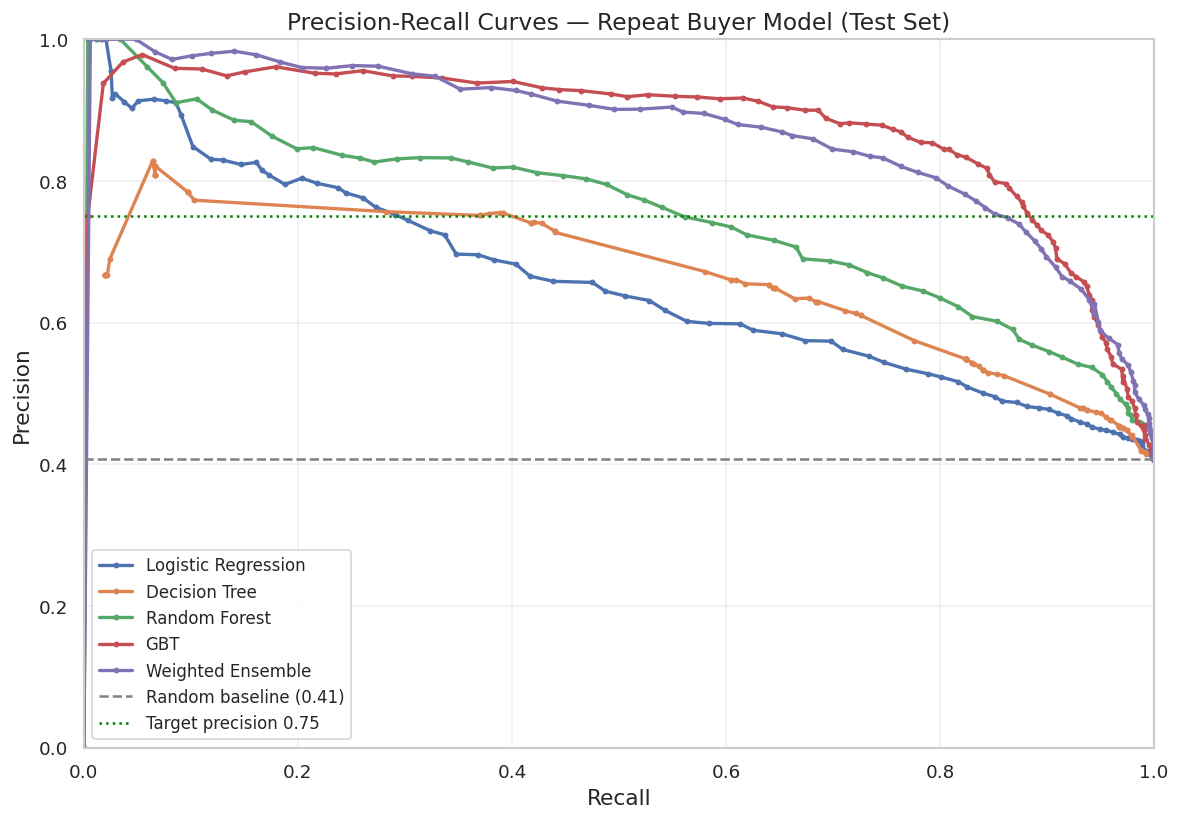

In [0]:
PR_GRID = [i / 100 for i in range(1, 100)]
fig, ax = plt.subplots(figsize=(10, 7))

for name, scored_pd in test_scored_cache.items():
    labels_k = scored_pd["label"].values
    probs_k = scored_pd["pos_prob"].values
    pr_pts = [eval_at_threshold(labels_k, probs_k, t / 100) for t in range(1, 100)]
    pr_df = pd.DataFrame(pr_pts).sort_values("recall")
    ax.plot(pr_df["recall"], pr_df["precision"], linewidth=2, marker="o", markersize=2.5, label=name)

base_rate = pos_pct / 100
ax.axhline(y=base_rate, color="gray", linestyle="--", linewidth=1.5, label=f"Random baseline ({base_rate:.2f})")
ax.axhline(y=0.75, color="green", linestyle=":", linewidth=1.5, label="Target precision 0.75")
ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision-Recall Curves — Repeat Buyer Model (Test Set)", fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section: Precision@K - Business Targeting Analysis
**"If we can only run a campaign for K% of users, who should we target?"**
Precision@K directly answers the marketing budget question.

Higher K = more reach; lower precision = more wasted spend.

In [0]:
best_pd = test_scored_cache[best_model_name]
labels_all = best_pd["label"].values
probs_all = best_pd["pos_prob"].values
total_test_users = len(labels_all)
base_rate_test = float(labels_all.mean())

print(f"Precision@K — {best_model_name}")
print(f"Test users: {total_test_users:,}  |  Base rate (random): {base_rate_test:.3f}\n")
print(f"{'K':>6} {'Threshold':>10} {'Users Targeted':>15} {'Precision@K':>13} {'Lift@K':>8} {'Business Read':>30}")
print("-" * 90)

for k in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]:
    n = max(1, int(total_test_users * k))
    top_idx = np.argsort(-probs_all)[:n]
    prec_k = float(labels_all[top_idx].mean())
    lift_k = prec_k / base_rate_test if base_rate_test else 0.0
    thr_k = float(probs_all[top_idx[-1]])
    biz = f"{prec_k * 100:.0f}% of targeted users return to buy"
    print(f"{k * 100:5.0f}% {thr_k:10.3f} {n:15,} {prec_k:13.4f} {lift_k:8.2f}x  {biz}")

Precision@K — GBT
Test users: 2,029  |  Base rate (random): 0.407

     K  Threshold  Users Targeted   Precision@K   Lift@K                  Business Read
------------------------------------------------------------------------------------------
    5%      0.918             101        0.9505     2.34x  95% of targeted users return to buy
   10%      0.871             202        0.9505     2.34x  95% of targeted users return to buy
   20%      0.785             405        0.9309     2.29x  93% of targeted users return to buy
   30%      0.676             608        0.9013     2.22x  90% of targeted users return to buy
   40%      0.525             811        0.8360     2.06x  84% of targeted users return to buy
   50%      0.388           1,014        0.7288     1.79x  73% of targeted users return to buy


## Section: Business Impact Summary

Translating model performance into **real business decisions**.
The model doubles campaign effectiveness versus random targeting.

In [0]:
best_row_full = comparison_pd[comparison_pd["Model"] == best_model_name].iloc[0]
prec = float(best_row_full["Precision"])
rec = float(best_row_full["Recall"])
f1 = float(best_row_full["F1"])

frac_targeted = (
    float(test_scored_cache[best_model_name]["pos_prob"].gt(best_thresholds.get(best_model_name, 0.5)).sum())
    / total_test_users
)
campaign_targets = int(frac_targeted * cohort_size)

true_returners_reached = int(campaign_targets * prec)
missed_returners = int(pos_users * (1 - rec))
random_campaign_hits = int(campaign_targets * base_rate)
lift_ratio = prec / base_rate if base_rate else 0.0

print("=" * 65)
print("BUSINESS IMPACT SUMMARY — Repeat Buyer Retention Model")
print("=" * 65)
print(f"\n  Model precision          : {prec:.1%}")
print(f"  Model recall             : {rec:.1%}")
print(f"  F1 Score                 : {f1:.4f}")
print()
print(f"  Full cohort (Oct–Dec buyers)  : {cohort_size:,} users")
print(f"  Confirmed repeat buyers       : {pos_users:,} ({pos_pct:.1f}%)")
print()
print("  ── Campaign Scenario (targeting predicted returners) ──")
print(f"  Users targeted by model       : ~{campaign_targets:,}")
print(f"  True repeat buyers reached    : ~{true_returners_reached:,} ({prec:.0%} of targeted)")
print(f"  Repeat buyers missed          : ~{missed_returners:,}")
print()
print(f"  Lift over random targeting    : {lift_ratio:.2f}×")
print(f"  Random campaign would convert : {int(campaign_targets * base_rate):,} of same budget")
print(f"  Additional conversions gained : ~{true_returners_reached - int(campaign_targets * base_rate):,}")
print()
print("  ── Strategic Implication ──")
print(f"  Same campaign budget → {lift_ratio:.1f}× more retained customers vs random outreach.")
print("=" * 65)

BUSINESS IMPACT SUMMARY — Repeat Buyer Retention Model

  Model precision          : 81.8%
  Model recall             : 84.4%
  F1 Score                 : 0.8305

  Full cohort (Oct–Dec buyers)  : 12,972 users
  Confirmed repeat buyers       : 5,287 (40.8%)

  ── Campaign Scenario (targeting predicted returners) ──
  Users targeted by model       : ~5,440
  True repeat buyers reached    : ~4,449 (82% of targeted)
  Repeat buyers missed          : ~826

  Lift over random targeting    : 2.01×
  Random campaign would convert : 2,217 of same budget
  Additional conversions gained : ~2,232

  ── Strategic Implication ──
  Same campaign budget → 2.0× more retained customers vs random outreach.


## Section: RFM Customer Segments
Segmenting Oct-Dec buyers by RFM quintile scores to identify actionable customer groups.
Each segment has a different return rate - drives differentiated retention strategies.

In [0]:
user_rfm = user_data.select("user_id", "label", "days_since_last_purchase", "purchase_count", "total_spend")

r_bounds = user_rfm.approxQuantile("days_since_last_purchase", [0.2, 0.4, 0.6, 0.8], 0.01)
f_bounds = user_rfm.approxQuantile("purchase_count", [0.2, 0.4, 0.6, 0.8], 0.01)
m_bounds = user_rfm.approxQuantile("total_spend", [0.2, 0.4, 0.6, 0.8], 0.01)


def quintile_score(col_name, bounds, reverse=False):
    """Assign quintile score 1–5 based on breakpoints."""
    col = F.col(col_name)
    if reverse:
        return (
            F.when(col <= bounds[0], 5)
            .when(col <= bounds[1], 4)
            .when(col <= bounds[2], 3)
            .when(col <= bounds[3], 2)
            .otherwise(1)
        )
    return (
        F.when(col <= bounds[0], 1)
        .when(col <= bounds[1], 2)
        .when(col <= bounds[2], 3)
        .when(col <= bounds[3], 4)
        .otherwise(5)
    )


rfm_scored = (
    user_rfm.withColumn("R", quintile_score("days_since_last_purchase", r_bounds, reverse=True))
    .withColumn("F", quintile_score("purchase_count", f_bounds))
    .withColumn("M", quintile_score("total_spend", m_bounds))
    .withColumn("rfm_score", F.col("R") + F.col("F") + F.col("M"))
    .withColumn(
        "segment",
        F.when(F.col("rfm_score") >= 13, "Champions")
        .when(F.col("rfm_score") >= 10, "Loyal Customers")
        .when((F.col("R") >= 4) & (F.col("rfm_score") >= 8), "Potential Loyalists")
        .when((F.col("R") >= 4) & (F.col("rfm_score") < 8), "Recent Customers")
        .when((F.col("R") <= 2) & (F.col("rfm_score") >= 10), "At-Risk High-Value")
        .when(F.col("R") <= 2, "Lost Customers")
        .otherwise("Needs Attention"),
    )
)

seg_summary = (
    rfm_scored.groupBy("segment")
    .agg(F.count("*").alias("users"), F.avg("label").alias("return_rate"), F.avg("total_spend").alias("avg_spend"))
    .orderBy(F.desc("return_rate"))
    .toPandas()
)

seg_summary["return_rate"] = seg_summary["return_rate"].map(lambda x: f"{x:.1%}")
seg_summary["avg_spend"] = seg_summary["avg_spend"].map(lambda x: f"${x:.2f}")
seg_summary["users"] = seg_summary["users"].map(lambda x: f"{x:,}")

print("=" * 65)
print("RFM CUSTOMER SEGMENTS — Repeat Purchase Rate by Segment")
print("=" * 65)
print(seg_summary.to_string(index=False))
print("=" * 65)

RFM CUSTOMER SEGMENTS — Repeat Purchase Rate by Segment
            segment users return_rate avg_spend
          Champions 2,035       66.4%   $273.50
    Loyal Customers 3,577       47.5%   $154.25
Potential Loyalists 1,082       37.9%    $58.52
    Needs Attention 1,254       35.2%    $59.60
   Recent Customers 1,008       32.1%    $32.46
     Lost Customers 4,016       26.4%    $73.03


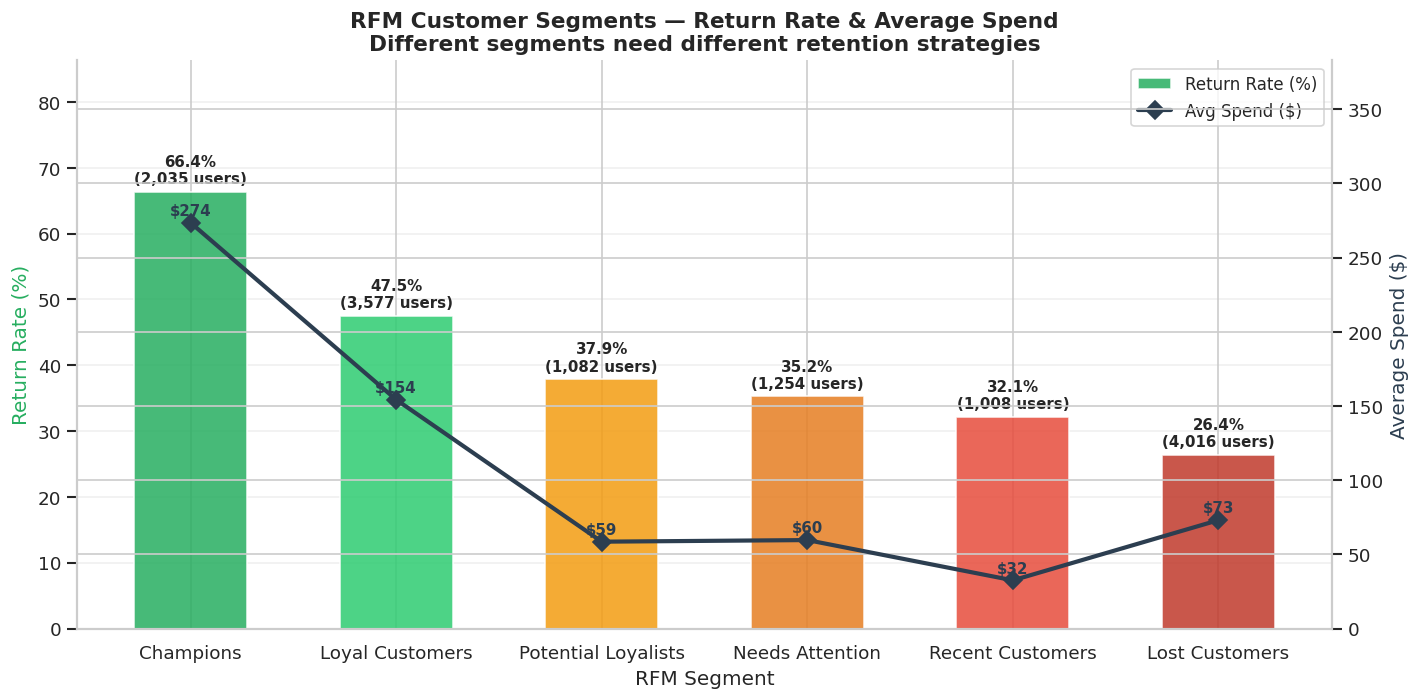

In [0]:
# Chart 4 — RFM Segments: Return Rate + Average Spend
# Dual-axis chart: bars show return rate per segment, line shows average spend.
# Makes the Champions vs Lost contrast immediately visible for business stakeholders.

_seg_raw = (
    rfm_scored.groupBy("segment")
    .agg(
        F.count("*").alias("users"),
        F.avg("label").alias("return_rate"),
        F.avg("total_spend").alias("avg_spend"),
    )
    .orderBy(F.desc("return_rate"))
    .toPandas()
)

_seg_names = _seg_raw["segment"].tolist()
_seg_rr = (_seg_raw["return_rate"] * 100).tolist()
_seg_spend = _seg_raw["avg_spend"].tolist()
_seg_users = _seg_raw["users"].tolist()
_bar_colors = ["#27ae60", "#2ecc71", "#f39c12", "#e67e22", "#e74c3c", "#c0392b"][: len(_seg_names)]

fig4, ax4a = plt.subplots(figsize=(12, 6))
ax4b = ax4a.twinx()

bars4 = ax4a.bar(_seg_names, _seg_rr, color=_bar_colors, alpha=0.85, width=0.55, label="Return Rate (%)")
ax4b.plot(
    _seg_names, _seg_spend, color="#2c3e50", marker="D", markersize=8, linewidth=2.5, label="Avg Spend ($)", zorder=5
)

for bar, rr, n in zip(bars4, _seg_rr, _seg_users):
    ax4a.text(
        bar.get_x() + bar.get_width() / 2,
        rr + 0.8,
        f"{rr:.1f}%\n({n:,} users)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

for i, spend in enumerate(_seg_spend):
    ax4b.text(i, spend + 3, f"${spend:.0f}", ha="center", va="bottom", fontsize=9, color="#2c3e50", fontweight="bold")

ax4a.set_xlabel("RFM Segment", fontsize=12)
ax4a.set_ylabel("Return Rate (%)", fontsize=12, color="#27ae60")
ax4b.set_ylabel("Average Spend ($)", fontsize=12, color="#2c3e50")
ax4a.set_ylim(0, max(_seg_rr) * 1.3)
ax4b.set_ylim(0, max(_seg_spend) * 1.4)
ax4a.set_title(
    "RFM Customer Segments — Return Rate & Average Spend\nDifferent segments need different retention strategies",
    fontsize=13,
    fontweight="bold",
)

lines4a, labels4a = ax4a.get_legend_handles_labels()
lines4b, labels4b = ax4b.get_legend_handles_labels()
ax4a.legend(lines4a + lines4b, labels4a + labels4b, fontsize=10, loc="upper right")
ax4a.grid(axis="y", alpha=0.3)
ax4a.spines[["top"]].set_visible(False)
ax4b.spines[["top"]].set_visible(False)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [0]:
print("=" * 65)
print("Customer Retention Model")
print("=" * 65)
print()
print(f"  Business Problem : Repeat Buyer Prediction (User-Level)")
print(f"  Best Model       : {winner['Model']}")
print(f"  Precision        : {winner['Precision']:.4f}")
print(f"  Recall           : {winner['Recall']:.4f}")
print(f"  F1 Score         : {winner['F1']:.4f}")
print(f"  AUC-ROC          : {winner['AUC-ROC']}")

Customer Retention Model

  Business Problem : Repeat Buyer Prediction (User-Level)
  Best Model       : GBT
  Precision        : 0.8179
  Recall           : 0.8436
  F1 Score         : 0.8305
  AUC-ROC          : 0.9137
